# About Dataset

----------------------------------------------------------------
* Introduction:
   * A collection of English Twitter messages meticulously annotated with six fundamental emotions: anger, fear, joy, love, sadness, and surprise. This dataset serves as a valuable resource for understanding and analyzing the diverse spectrum of emotions expressed in short-form text on social media.
   * Each entry in this dataset consists of a text segment representing a Twitter message and a corresponding label indicating the predominant emotion conveyed. The emotions are classified into six categories: sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5). 

* Key Features:
  * text: A string feature representing the content of the Twitter message.
  * label: A classification label indicating the primary emotion, with values ranging from 0 to 5.

----------------------------------------------------------------

# Exploring the dataset

----------------------------------------------------------------

In [8]:
import pandas as pd
import numpy as np
import re
import string
import unicodedata
import contractions
import emoji
from collections import Counter
from spellchecker import SpellChecker
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import joblib
import pickle
import spacy
import nltk
from nltk.corpus import stopwords
from nltk import ngrams
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import load_model

In [2]:
df = pd.read_csv(r"C:\Users\dell\Downloads\datasets\data.csv")

In [8]:
df.head()

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [9]:
df.sample(3)

,text,label
256801,i still listened to the occasional jobro song ...,2
333708,i feel like they mix in really well with the o...,1
350680,i find it odd to be feeling sympathetic toward...,2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


In [11]:
print("Missing values in emotion_df:")

print(df.isna().sum())

Missing values in emotion_df:
text     0
label    0
dtype: int64


In [12]:
print(f'The number of duplicated rows are : {df.duplicated().sum()}')

The number of duplicated rows are : 686


In [3]:
label_map = {0:"sadness",1:"joy",2:"love",3:"anger",4:"fear",5:"surprise"}
df["label_name"] = df["label"].map(label_map)

In [4]:
# Text length in characters
df["char_count"] = df["text"].apply(len)

# Word count
df["word_count"] = df["text"].apply(lambda x: len(x.split()))


In [15]:
# Summary statistics
df[["char_count","word_count"]].describe()

,char_count,word_count
count,416809.000000,416809.000000
mean,97.028397,19.211015
std,56.198232,11.051049
min,2.000000,1.000000
25%,54.000000,11.000000
50%,86.000000,17.000000
75%,128.000000,25.000000
max,830.000000,178.000000


In [28]:
# Combine all texts into one big string
all_words = " ".join(df["text"]).split()
# Convert to a set to keep only unique words
vocab_size = len(set(all_words))
print("Vocabulary size:", vocab_size)

Vocabulary size: 75302


In [21]:
#Counts how many times each unique word appears in all_words
word_freq = Counter(all_words)
word_freq.most_common(20)

[('i', 676203),
 ('feel', 289939),
 ('and', 250279),
 ('to', 233106),
 ('the', 216648),
 ('a', 162914),
 ('feeling', 134185),
 ('that', 130733),
 ('of', 129993),
 ('my', 111199),
 ('in', 86434),
 ('it', 84465),
 ('like', 73972),
 ('so', 65014),
 ('for', 64050),
 ('im', 61662),
 ('have', 61334),
 ('me', 60494),
 ('but', 58592),
 ('was', 57557)]

In [22]:
for label in df["label"].unique():
    words = " ".join(df[df["label"]==label]["text"]).split()
    word_freq = Counter(words)
    print(f"\nTop words for label {label}:")
    print(word_freq.most_common(10))


Top words for label 0:
[('i', 198644), ('feel', 84184), ('and', 70589), ('to', 60555), ('the', 56262), ('a', 43643), ('feeling', 40849), ('of', 35094), ('that', 34696), ('my', 31895)]

Top words for label 1:
[('i', 225154), ('feel', 102709), ('and', 86957), ('to', 85554), ('the', 79354), ('a', 56767), ('that', 48872), ('of', 44480), ('feeling', 40953), ('my', 37210)]

Top words for label 2:
[('i', 56675), ('feel', 24463), ('and', 22462), ('the', 21567), ('to', 20979), ('a', 15772), ('of', 13461), ('that', 11769), ('my', 11453), ('feeling', 10303)]

Top words for label 3:
[('i', 93430), ('feel', 37717), ('and', 33570), ('to', 30176), ('the', 27873), ('a', 21523), ('feeling', 19236), ('that', 17073), ('of', 16617), ('my', 14297)]

Top words for label 4:
[('i', 77495), ('feel', 30913), ('to', 28211), ('and', 27600), ('the', 23126), ('a', 18875), ('feeling', 17673), ('of', 15450), ('that', 13323), ('my', 12553)]

Top words for label 5:
[('i', 24805), ('feel', 9953), ('and', 9101), ('the',

<B> Word Cloud <B>
* A word cloud is a visual representation of text data in which the frequency of each word's occurrence is depicted by the size of the word. Words that appear more frequently in the text are typically displayed with a larger font size, while less frequent words are smaller.
* 
Word clouds are often used to quickly and visually summarize the most common words or themes within a large body of text. They are popular in data analysis, text mining, and visualization tasks, as they provide a simple yet effective way to identify patterns and trends in textual data.

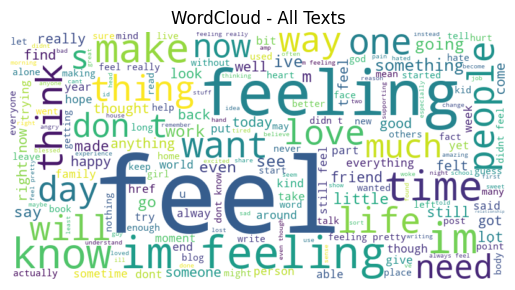

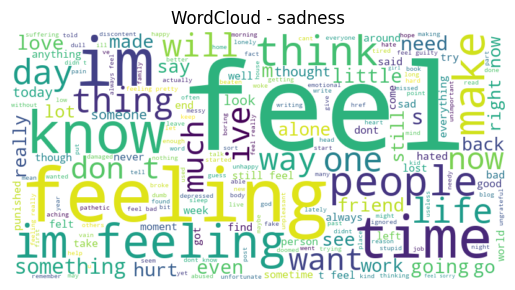

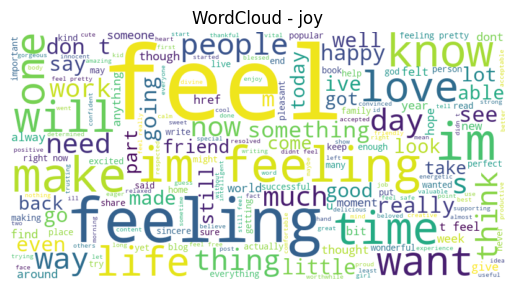

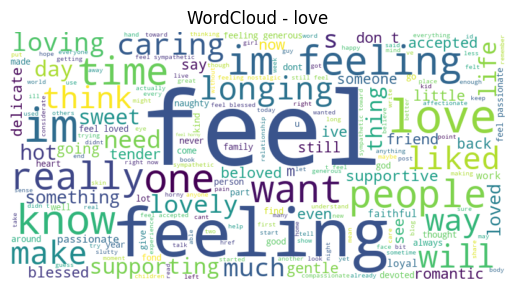

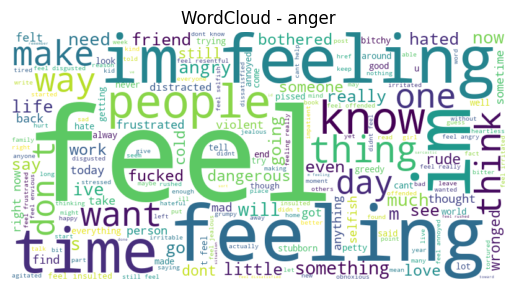

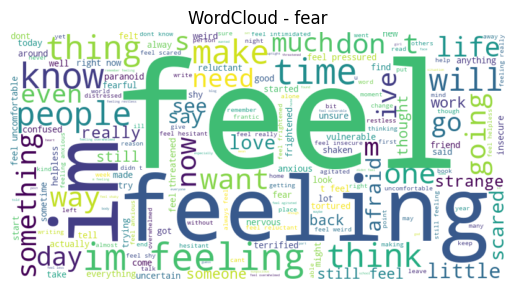

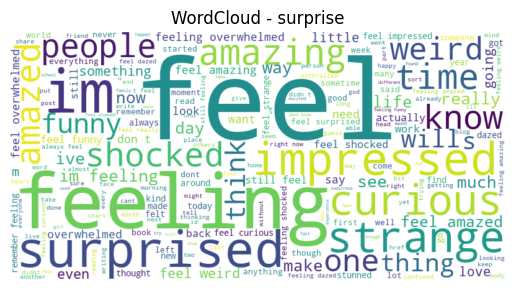

In [23]:
# Overall
text_all = " ".join(df["text"])
wc = WordCloud(width=800, height=400, background_color="white").generate(text_all)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - All Texts")
plt.show()

# Per class
for label in df["label_name"].unique():
    text = " ".join(df[df["label_name"]==label]["text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {label}")
    plt.show()


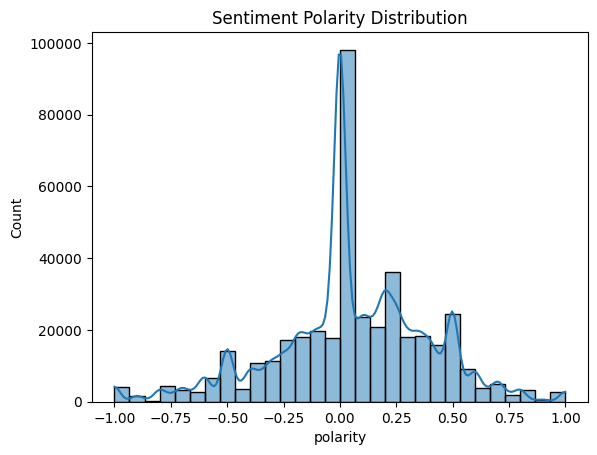

In [9]:
#This column represents how positive or negative each text is.
df["polarity"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)
#This column represents how factual vs. opinionated the text is.
df["subjectivity"] = df["text"].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Plot polarity distribution
sns.histplot(df["polarity"], bins=30, kde=True)
plt.title("Sentiment Polarity Distribution")
plt.show()


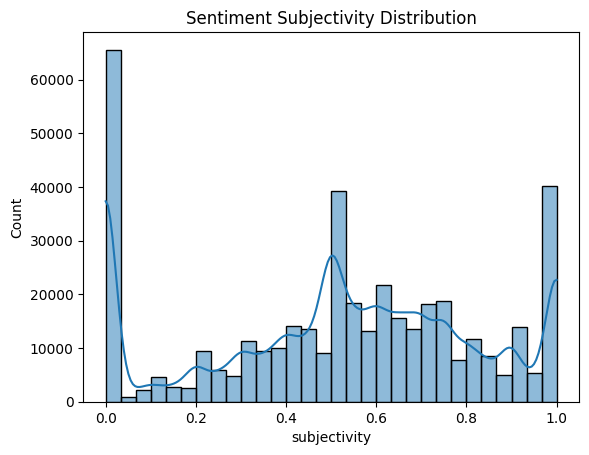

In [25]:
# Plot subjectivity distribution
sns.histplot(df["subjectivity"], bins=30, kde=True)
plt.title("Sentiment Subjectivity Distribution")
plt.show()

* The peak is centered at 0 → most of texts are neutral (neither strongly positive nor negative).
* But there’s still a spread toward both negative (<0) and positive (>0), which meanshaving some emotional content.
* Dataset is dominated by neutral statements.
* Sentiment classification might need balancing (since positive/negative are fewer compared to neutral).

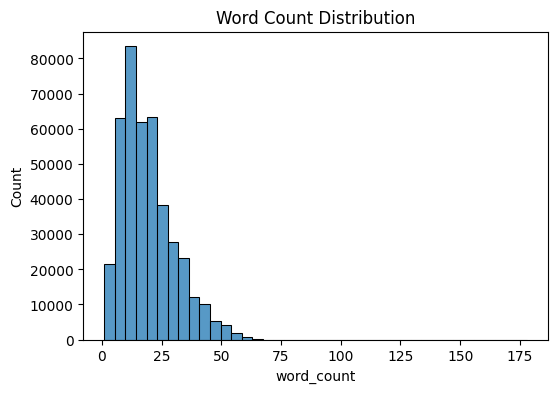

In [27]:
# word per text histogram
plt.figure(figsize=(6,4))
sns.histplot(df["word_count"], bins=40, kde=False)
plt.title("Word Count Distribution")
plt.show()


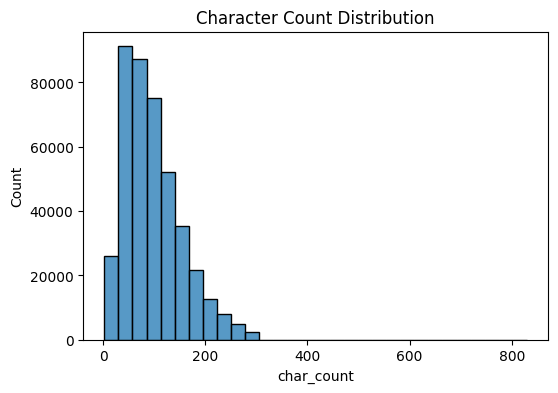

In [28]:
# Characters per text histogram
plt.figure(figsize=(6,4))
sns.histplot(df["char_count"], bins=30, kde=False)
plt.title("Character Count Distribution")
plt.show()

             Count  Percentage
label_name                    
joy         141067       33.84
sadness     121187       29.07
anger        57317       13.75
fear         47712       11.45
love         34554        8.29
surprise     14972        3.59


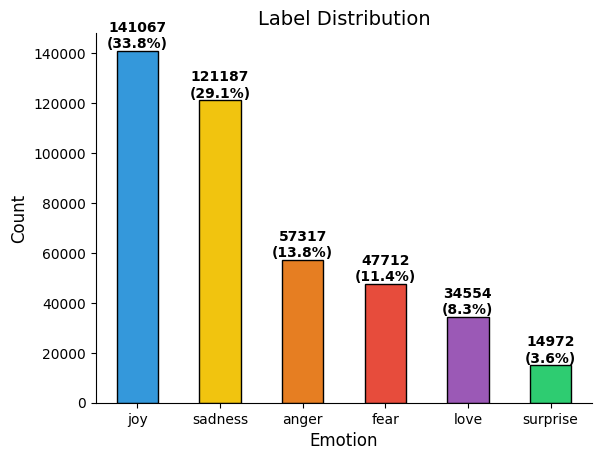

In [29]:
# Count values and calculate percentages
label_counts = df["label_name"].value_counts()
label_percent = df["label_name"].value_counts(normalize=True) * 100

label_distribution = pd.DataFrame({
    "Count": label_counts,
    "Percentage": label_percent.round(2)  
})
print(label_distribution)

#plot
colors = ["#3498db", "#f1c40f", "#e67e22", "#e74c3c", "#9b59b6", "#2ecc71"]
fig, ax = plt.subplots()
label_counts.plot(kind="bar", color=colors, edgecolor="black", ax=ax)

#add counts & percentages on top of bars
for i, count in enumerate(label_counts):
    pct = label_percent.iloc[i]
    ax.text(i, count + 0.5, f"{count}\n({pct:.1f}%)", 
            ha='center', va='bottom', fontsize=10, fontweight="bold")

ax.set_title("Label Distribution", fontsize=14)
ax.set_xlabel("Emotion", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticklabels(label_counts.index, rotation=0)

#Remove top and right borders 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

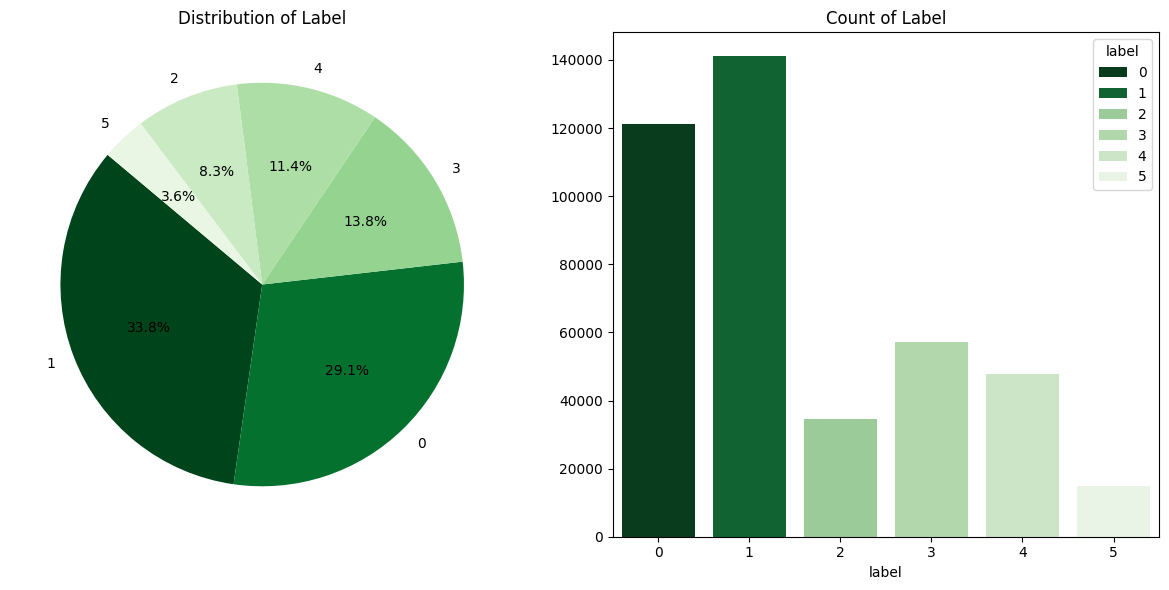

In [7]:
count = df['label'].value_counts()

# Create a colormap
cmap = plt.cm.Greens

# Get a list of colors from the colormap, mapping the normalized counts to the color range
colors = [cmap(i) for i in count.values / count.values.max()]

# Create the figure and axes for the plots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# Pie chart
# The labels are now integers, so convert them to strings for plotting
axs[0].pie(count.values, labels=count.index.astype(str), autopct='%1.1f%%',
           startangle=140, colors=colors)
axs[0].set_title('Distribution of Label')

# Bar chart
# Use the `palette` argument with the pre-calculated list of colors
sns.barplot(
    x=count.index,
    y=count.values,
    ax=axs[1],
    hue=count.index,
    palette=colors
)
axs[1].set_title('Count of Label')

# Ensure labels are not truncated
plt.tight_layout()

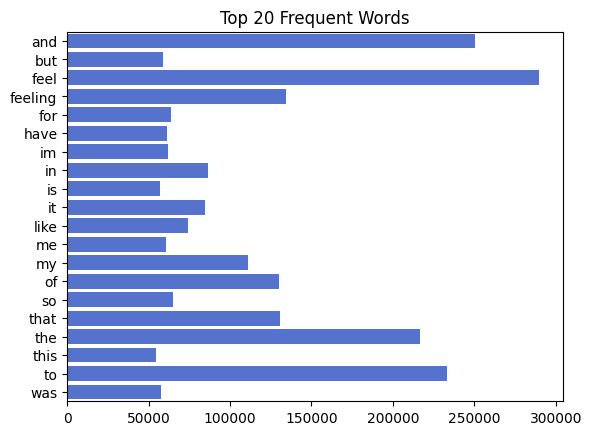

In [30]:
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df["text"])
word_counts = np.asarray(X.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

sns.barplot(x=word_counts, y=words, color="royalblue")
plt.title("Top 20 Frequent Words")
plt.show()


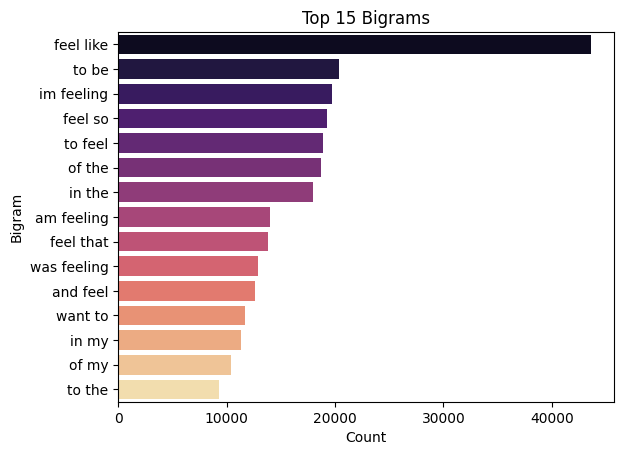

In [31]:
#extract only bigrams (two consecutive words).
cv = CountVectorizer(ngram_range=(2,2), max_features=15)
X = cv.fit_transform(df["text"])
sum_words = X.sum(axis=0).A1
words_freq = [(word, sum_words[idx]) for word, idx in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

bigram_df = pd.DataFrame(words_freq, columns=["Bigram","Count"])
sns.barplot(
    x="Count",
    y="Bigram",
    data=bigram_df,
    palette="magma",
    hue="Bigram",
    legend=False
)
plt.title("Top 15 Bigrams")
plt.show()


In [32]:
df["label"].value_counts()

label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

-----------------------------------------------------------------------------------
* The dataset contains 416809 rows with 2 columns
* The dataset is not balanced
* The dataset contains no null values
* It contains 686 duplications
* 75K unique words → the dataset is diverse in wording (many unique terms, spellings, or variations)
* Emotional expression is highly centered around feeling-related vocabulary, which validates the dataset’s relevance for emotion classification
* Some noisy bigrams like “href http” (leftover from URLs) appear — this suggests you should clean the text further (remove links/HTML).
* Emotional language is structured in predictable templates (“I feel like…”, “I’m feeling…”). This could be useful for feature engineering or building rules for emotion detection.
* Also, the stop words are dominant here
* The dataset needs some preprocessing (text cleaning)
------------------------------------------------------------------------------------

# Text preprocessing

--------------------------------------------

* text preprocessing:
  * Data quality significantly influences the performance of a machine-learning model. Inadequate or low-quality data can lead to lower accuracy and effectiveness of the model.
  * In general, text data derived from natural language is unstructured and noisy. So text preprocessing is a critical step to transform messy, unstructured text data into a form that can be effectively used to train machine learning models, leading to better results and insights.
  * Text preprocessing refers to a series of techniques used to clean, transform and prepare raw textual data into a format that is suitable for NLP or ML tasks. The goal of text preprocessing is to enhance the quality and usability of the text data for subsequent analysis or modeling.
    

* Raw text data is usually noisy and unstructured, containing various inconsistencies such as typos, slang, abbreviations and irrelevant information. Preprocessing helps in:
     * Improving Data Quality: Removing noise and irrelevant information ensures that the data fed into the model is clean and consistent.
     * Enhancing Model Performance: Well-preprocessed text can lead to better feature extraction, improving the performance of NLP models.
     * Reducing Complexity: Simplifying the text data can reduce the computational complexity and make the models more efficient.

## Text cleaning

* Remove irrelevant or noisy parts of the text.
* Always first → before anything else, because raw data is noisy.
  * Lowercasing → convert everything to lowercase ("Hello" → "hello") to avoid duplicates.
  * Removing HTML tags → (<>).
  * Removing URLs & emails → http://example.com → "".
  * Removing numbers (if not useful) → "I have 2 cats" → "I have cats".
  * Removing special characters/punctuation → hello!!! → hello.
  * Expanding contractions → "don't" → "do not".
  * Normalize accented characters – résumé → resume.

In [13]:
df.columns

Index(['text', 'label', 'label_name', 'char_count', 'word_count', 'polarity',
       'subjectivity'],
      dtype='object')

In [14]:
df.drop(["label_name",'char_count','word_count','polarity','subjectivity'],axis = 1,inplace = True)

In [18]:
df.columns

Index(['text', 'label'], dtype='object')

In [5]:
df.drop_duplicates()

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2
...,...,...
416804,that was what i felt when i was finally accept...,1
416805,i take every day as it comes i m just focussin...,4
416806,i just suddenly feel that everything was fake,0
416807,im feeling more eager than ever to claw back w...,1


In [29]:
def clean_text(text):
    #Lowercasing
    text = text.lower()
    
    #Expand contractions (don't -> do not, it'll -> it will)
    text = contractions.fix(text)
    
    #Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    #Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    #Remove emails
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    
    #Remove numbers 
    text = re.sub(r"\d+", " ", text)
    
    #Remove emojis (convert to words or drop)
    text = emoji.replace_emoji(text, replace="")  
    
    #Normalize accented characters (résumé → resume)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")
    
    #Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    #Remove extra whitespaces
    text = re.sub(r"\s+", " ", text).strip()

    #Remove special characters
    text = re.sub(r'\W', ' ', text)  

    
    return text


In [9]:
# Apply on a specific column
df["cleaned_text"] = df["text"].apply(clean_text)

In [71]:
df

,text,label,cleaned_text
0,i feel awful about it too because it s my job ...,0,i feel awful about it too because it s my job ...
1,im alone i feel awful,0,i am alone i feel awful
2,ive probably mentioned this before but i reall...,1,i have probably mentioned this before but i re...
3,i was feeling a little low few days back,0,i was feeling a little low few days back
4,i beleive that i am much more sensitive to oth...,2,i beleive that i am much more sensitive to oth...
...,...,...,...
416804,that was what i felt when i was finally accept...,1,that was what i felt when i was finally accept...
416805,i take every day as it comes i m just focussin...,4,i take every day as it comes i m just focussin...
416806,i just suddenly feel that everything was fake,0,i just suddenly feel that everything was fake
416807,im feeling more eager than ever to claw back w...,1,i am feeling more eager than ever to claw back...


## Tokenization

* Breaking text into smaller units (words) so that a machine learning model can understand and process it as ML models cannot process raw text directly—they need numerical features. Tokenization is the first step to convert text into features.

In [14]:
nlp = spacy.load("en_core_web_sm")
def spacy_tokenizer_pipe(texts):
    tokens_list = []
    for doc in nlp.pipe(texts, batch_size=500, n_process=-1):  # parallel processing
        tokens_list.append([token.text for token in doc if not token.is_punct and not token.is_space])
    return tokens_list

df["tokens"] = spacy_tokenizer_pipe(df["cleaned_text"].astype(str).tolist())


## Stopword Removal

* Remove common words that don’t add meaning in most contexts

In [33]:
stop = stopwords.words('english')
stop

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [16]:
# Define stopwords to keep
keep_stopwords = set([
  'again','against','all','any','aren','below','couldn','didn','doesn','down','few','further', 'hadn', 'hasn',
  'haven','more','most','mustn','needn','no', 'nor', 'not','out','over','own','shan', 'shouldn','under','up', 'very','wasn','weren','won',
   'too','until','at','by', 'of','off','on'

])

# Create a new stopword list excluding the important words
custom_stopwords = {word for word in stop if word not in keep_stopwords}

def remove_stopwords_from_tokens(tokens):
    return [token for token in tokens if token not in custom_stopwords]

df["cleaned_tokens"] = df["tokens"].apply(remove_stopwords_from_tokens)

In [20]:
df

,text,label,cleaned_text,tokens,cleaned_tokens
0,i feel awful about it too because it s my job ...,0,i feel awful about it too because it s my job ...,"[i, feel, awful, about, it, too, because, it, ...","[feel, awful, too, job, get, position, succeed..."
1,im alone i feel awful,0,i am alone i feel awful,"[i, am, alone, i, feel, awful]","[alone, feel, awful]"
2,ive probably mentioned this before but i reall...,1,i have probably mentioned this before but i re...,"[i, have, probably, mentioned, this, before, b...","[probably, mentioned, really, feel, proud, act..."
3,i was feeling a little low few days back,0,i was feeling a little low few days back,"[i, was, feeling, a, little, low, few, days, b...","[feeling, little, low, few, days, back]"
4,i beleive that i am much more sensitive to oth...,2,i beleive that i am much more sensitive to oth...,"[i, beleive, that, i, am, much, more, sensitiv...","[beleive, much, more, sensitive, peoples, feel..."
...,...,...,...,...,...
416804,that was what i felt when i was finally accept...,1,that was what i felt when i was finally accept...,"[that, was, what, i, felt, when, i, was, final...","[felt, finally, accepted, bulgarian, conservat..."
416805,i take every day as it comes i m just focussin...,4,i take every day as it comes i m just focussin...,"[i, take, every, day, as, it, comes, i, m, jus...","[take, every, day, comes, focussing, eating, b..."
416806,i just suddenly feel that everything was fake,0,i just suddenly feel that everything was fake,"[i, just, suddenly, feel, that, everything, wa...","[suddenly, feel, everything, fake]"
416807,im feeling more eager than ever to claw back w...,1,i am feeling more eager than ever to claw back...,"[i, am, feeling, more, eager, than, ever, to, ...","[feeling, more, eager, ever, claw, back, went,..."


## Lemmatization
* Lemmatization ensures all words are reduced to their true dictionary form (uses grammar + vocab), making the dataset cleaner, smaller, and more meaningful.

In [ ]:
def lemmatize_tokens_batch(token_lists, batch_size=500):
    texts = [" ".join(tokens) for tokens in token_lists]  # join tokens into string
    lemmatized_results = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=-1):
        lemmatized_results.append([token.lemma_ for token in doc if token.is_alpha])
    return lemmatized_results


df["lemmatized"] = lemmatize_tokens_batch(df["cleaned_tokens"])

In [24]:
df

,text,label,cleaned_text,tokens,cleaned_tokens,lemmatized
0,i feel awful about it too because it s my job ...,0,i feel awful about it too because it s my job ...,"[i, feel, awful, about, it, too, because, it, ...","[feel, awful, too, job, get, position, succeed...","[feel, awful, too, job, get, position, succeed..."
1,im alone i feel awful,0,i am alone i feel awful,"[i, am, alone, i, feel, awful]","[alone, feel, awful]","[alone, feel, awful]"
2,ive probably mentioned this before but i reall...,1,i have probably mentioned this before but i re...,"[i, have, probably, mentioned, this, before, b...","[probably, mentioned, really, feel, proud, act...","[probably, mention, really, feel, proud, actua..."
3,i was feeling a little low few days back,0,i was feeling a little low few days back,"[i, was, feeling, a, little, low, few, days, b...","[feeling, little, low, few, days, back]","[feel, little, low, few, day, back]"
4,i beleive that i am much more sensitive to oth...,2,i beleive that i am much more sensitive to oth...,"[i, beleive, that, i, am, much, more, sensitiv...","[beleive, much, more, sensitive, peoples, feel...","[beleive, much, more, sensitive, people, feeli..."
...,...,...,...,...,...,...
416804,that was what i felt when i was finally accept...,1,that was what i felt when i was finally accept...,"[that, was, what, i, felt, when, i, was, final...","[felt, finally, accepted, bulgarian, conservat...","[felt, finally, accept, bulgarian, conservator..."
416805,i take every day as it comes i m just focussin...,4,i take every day as it comes i m just focussin...,"[i, take, every, day, as, it, comes, i, m, jus...","[take, every, day, comes, focussing, eating, b...","[take, every, day, come, focusse, eat, well, m..."
416806,i just suddenly feel that everything was fake,0,i just suddenly feel that everything was fake,"[i, just, suddenly, feel, that, everything, wa...","[suddenly, feel, everything, fake]","[suddenly, feel, everything, fake]"
416807,im feeling more eager than ever to claw back w...,1,i am feeling more eager than ever to claw back...,"[i, am, feeling, more, eager, than, ever, to, ...","[feeling, more, eager, ever, claw, back, went,...","[feel, more, eager, ever, claw, back, go, pear..."


## Spelling correction

In [129]:
# Initialize spell checker
spell = SpellChecker(distance=1)

def correct_spelling_batch(token_lists, batch_size=500):
    corrected_all = []
    
    for i in range(0, len(token_lists), batch_size):
        batch = token_lists[i:i+batch_size]
        batch_corrected = []
        
        for tokens in batch:
            corrected_tokens = [
                spell.correction(token) if token.isalpha() else token
                for token in tokens
            ]
            batch_corrected.append(corrected_tokens)
        
        corrected_all.extend(batch_corrected)
    
    return corrected_all

df['lemmatized_corrected'] = correct_spelling_batch(df['lemmatized'], batch_size=500)

In [28]:
df

,text,label,cleaned_text,tokens,cleaned_tokens,lemmatized,lemmatized_corrected
0,i feel awful about it too because it s my job ...,0,i feel awful about it too because it s my job ...,"[i, feel, awful, about, it, too, because, it, ...","[feel, awful, too, job, get, position, succeed...","[feel, awful, too, job, get, position, succeed...","[feel, awful, too, job, get, position, succeed..."
1,im alone i feel awful,0,i am alone i feel awful,"[i, am, alone, i, feel, awful]","[alone, feel, awful]","[alone, feel, awful]","[alone, feel, awful]"
2,ive probably mentioned this before but i reall...,1,i have probably mentioned this before but i re...,"[i, have, probably, mentioned, this, before, b...","[probably, mentioned, really, feel, proud, act...","[probably, mention, really, feel, proud, actua...","[probably, mention, really, feel, proud, actua..."
3,i was feeling a little low few days back,0,i was feeling a little low few days back,"[i, was, feeling, a, little, low, few, days, b...","[feeling, little, low, few, days, back]","[feel, little, low, few, day, back]","[feel, little, low, few, day, back]"
4,i beleive that i am much more sensitive to oth...,2,i beleive that i am much more sensitive to oth...,"[i, beleive, that, i, am, much, more, sensitiv...","[beleive, much, more, sensitive, peoples, feel...","[beleive, much, more, sensitive, people, feeli...","[believe, much, more, sensitive, people, feeli..."
...,...,...,...,...,...,...,...
416804,that was what i felt when i was finally accept...,1,that was what i felt when i was finally accept...,"[that, was, what, i, felt, when, i, was, final...","[felt, finally, accepted, bulgarian, conservat...","[felt, finally, accept, bulgarian, conservator...","[felt, finally, accept, bulgarian, conservatoi..."
416805,i take every day as it comes i m just focussin...,4,i take every day as it comes i m just focussin...,"[i, take, every, day, as, it, comes, i, m, jus...","[take, every, day, comes, focussing, eating, b...","[take, every, day, come, focusse, eat, well, m...","[take, every, day, come, focuses, eat, well, m..."
416806,i just suddenly feel that everything was fake,0,i just suddenly feel that everything was fake,"[i, just, suddenly, feel, that, everything, wa...","[suddenly, feel, everything, fake]","[suddenly, feel, everything, fake]","[suddenly, feel, everything, fake]"
416807,im feeling more eager than ever to claw back w...,1,i am feeling more eager than ever to claw back...,"[i, am, feeling, more, eager, than, ever, to, ...","[feeling, more, eager, ever, claw, back, went,...","[feel, more, eager, ever, claw, back, go, pear...","[feel, more, eager, ever, claw, back, go, pear..."


In [ ]:
df.to_csv("processed_text.csv", index=False)

In [12]:
df = pd.read_csv("processed_text.csv")


--------------------------------------

# Visualization

-----------------------------------

In [87]:
import ast

# Convert string representation of lists to actual lists
df["lemmatized_str"] = df["lemmatized_corrected"].apply(ast.literal_eval)


In [88]:
print(df["lemmatized_corrected"].head())
print(type(df["lemmatized_corrected"].iloc[0]))


0    [feel, awful, too, job, get, position, succeed...
1                                 [alone, feel, awful]
2    [probably, mention, really, feel, proud, actua...
3                  [feel, little, low, few, day, back]
4    [believe, much, more, sensitive, people, feeli...
Name: lemmatized_corrected, dtype: object
<class 'list'>


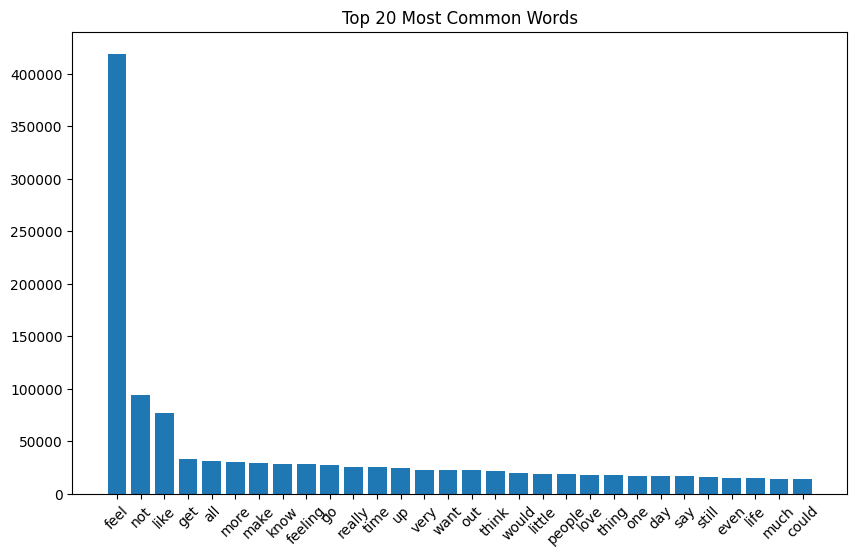

In [101]:
# Flatten the tokens but keep only strings
all_tokens = [
    word for tokens in df["lemmatized_corrected"]
    for word in tokens if isinstance(word, str) and word.strip() != ""
]

# Count frequencies
word_freq = Counter(all_tokens).most_common(30)

# Plot
words, counts = zip(*word_freq)
plt.figure(figsize=(10,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words")
plt.show()


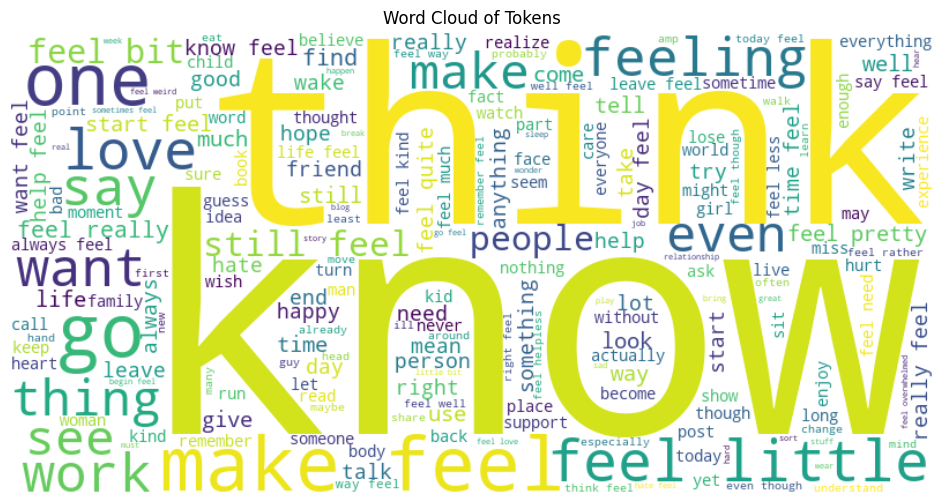

In [97]:
text_data = " ".join(all_tokens)

wc = WordCloud(width=800, height=400, background_color="white").generate(text_data)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Tokens")
plt.show()

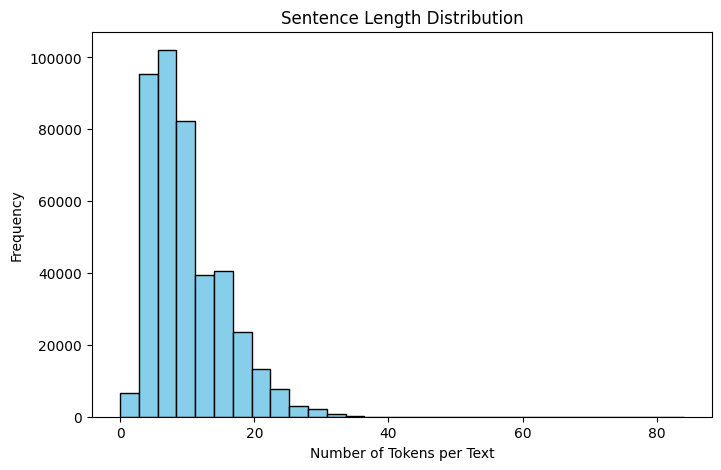

In [103]:
lengths = df["lemmatized_corrected"].apply(len)

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Number of Tokens per Text")
plt.ylabel("Frequency")
plt.title("Sentence Length Distribution")
plt.show()


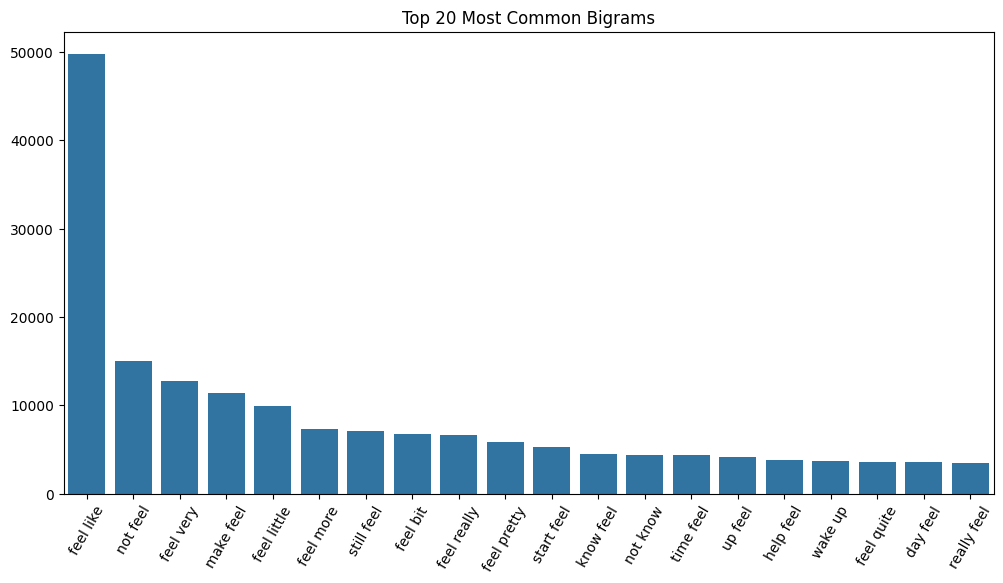

In [111]:
# Create bigrams
bigrams = list(ngrams(all_tokens, 2))
bigram_freq = Counter(bigrams).most_common(20)

# Plot
bigrams_words = [' '.join(b) for b, _ in bigram_freq]
counts = [c for _, c in bigram_freq]

plt.figure(figsize=(12,6))
sns.barplot(x=bigrams_words, y=counts)
plt.xticks(rotation=60)
plt.title("Top 20 Most Common Bigrams")
plt.show()


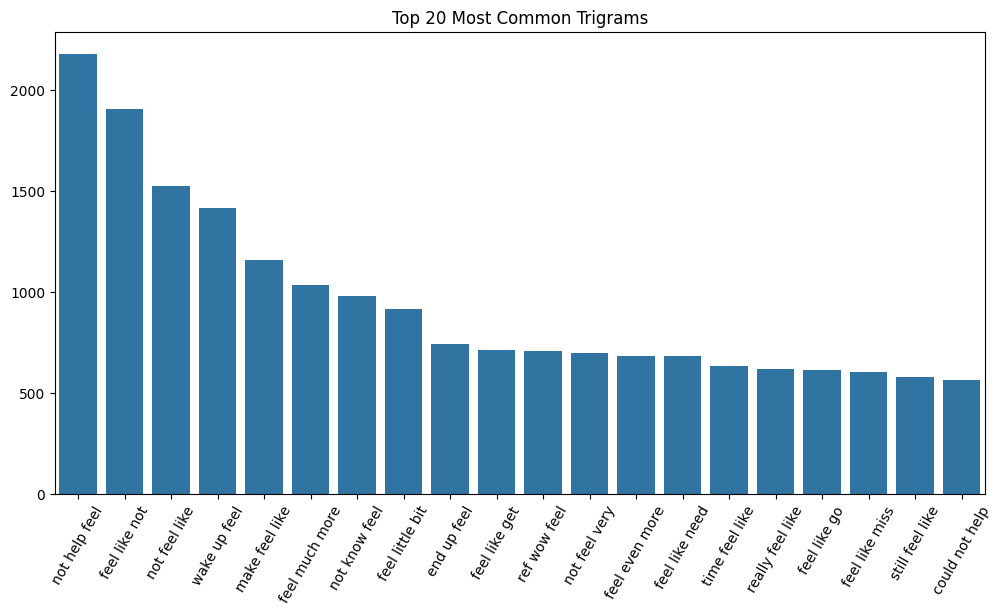

In [115]:
# Create bigrams
trigrams = list(ngrams(all_tokens, 3))
trigram_freq = Counter(trigrams).most_common(20)

# Plot
trigrams_words = [' '.join(b) for b, _ in trigram_freq]
counts = [c for _, c in trigram_freq]

plt.figure(figsize=(12,6))
sns.barplot(x=trigrams_words, y=counts)
plt.xticks(rotation=60)
plt.title("Top 20 Most Common Trigrams")
plt.show()


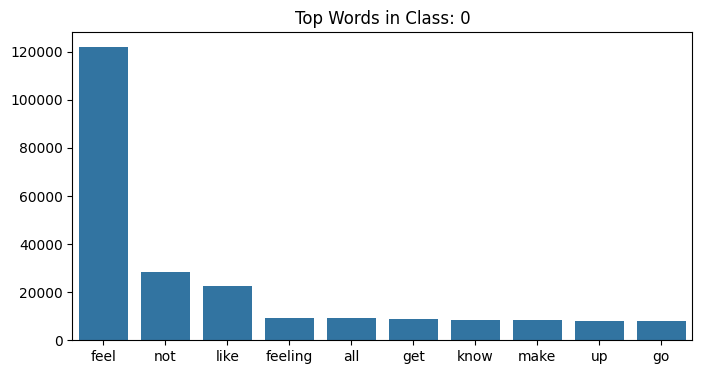

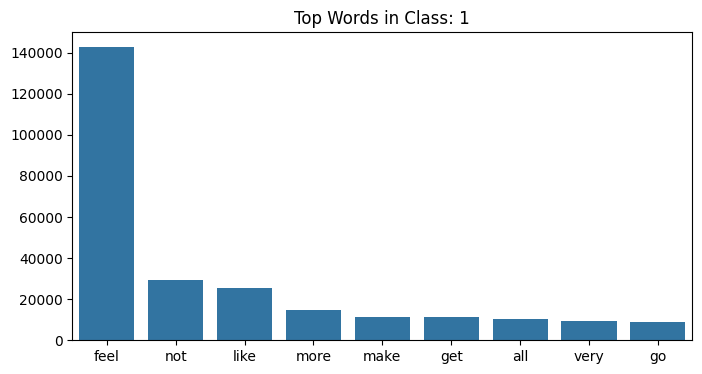

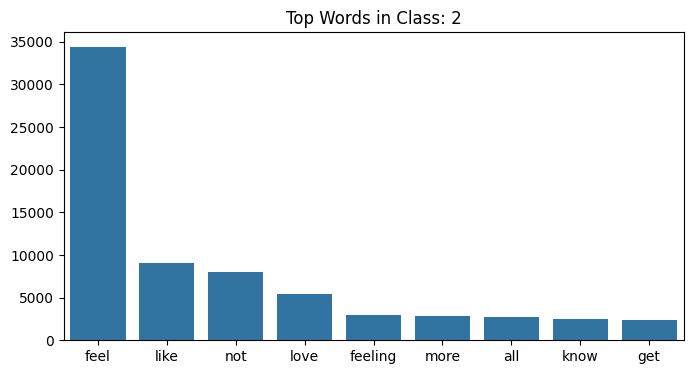

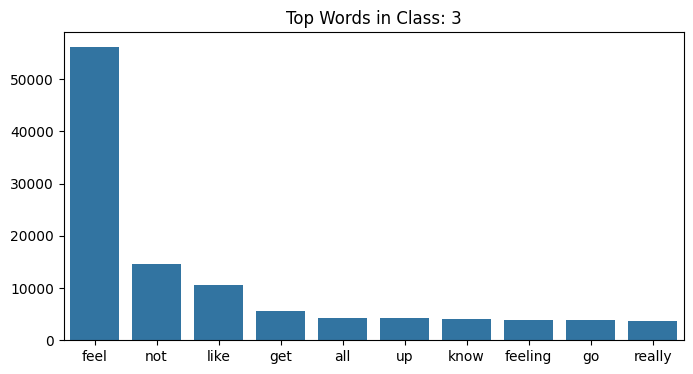

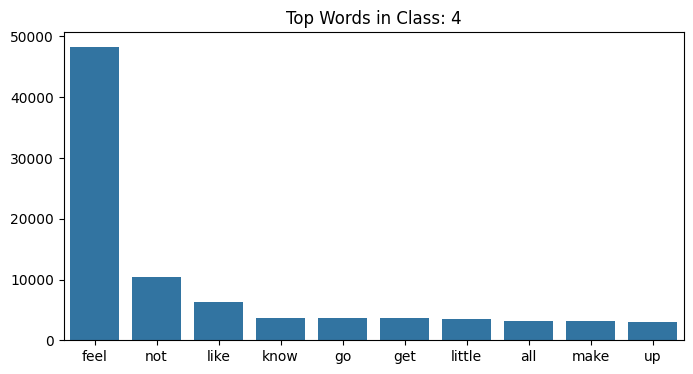

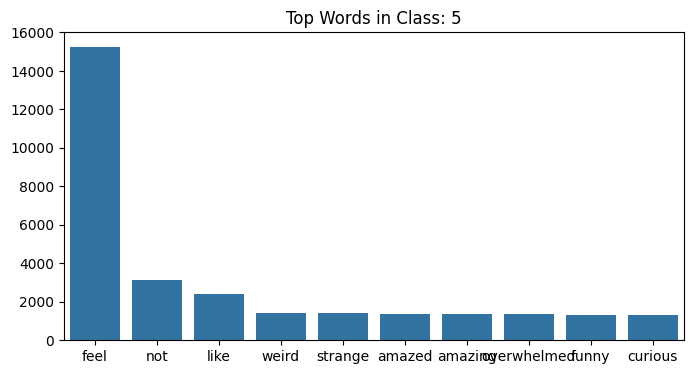

In [119]:
class_words = df.groupby("label")["lemmatized_corrected"].apply(lambda x: [w for tokens in x for w in tokens])

for label, words in class_words.items():
    top_words = Counter(words).most_common(10)
    w, c = zip(*top_words)
    plt.figure(figsize=(8,4))
    sns.barplot(x=list(w), y=list(c))
    plt.title(f"Top Words in Class: {label}")
    plt.show()


-----------------------------------------------------------------------------------------

# Text representation

---------------------------------------------------------------

* Text representation means how we convert raw text into a form that a computer (or ML model) can understand and work with.
  
* Bag of Words (BoW)
  
  * Represents text as a collection of words, ignoring order.

* TF-IDF (Term Frequency – Inverse Document Frequency)
  
  * Like BoW, but it also considers importance of words.
    
* Word Embeddings (Word2Vec, GloVe, FastText)
  
  * Represent words as dense vectors in a continuous space.
  * Words with similar meaning have similar vectors.
    
* BERT (Bidirectional Encoder Representations from Transformers)
  
  * It is a deep learning–based embedding model.
  * It produces contextual word embeddings, meaning the representation of a word changes depending on its context
    
* Classical ML models → BoW, TF-IDF, or averaged Word2Vec.

* Deep Learning models → Word2Vec embeddings, BERT (and transformer embeddings). 

In [13]:
df["data"] = df["lemmatized_corrected"].apply(lambda x: re.sub(r"[\[\]',]", "", x))
df["data"].head()

0    feel awful too job get position succeed did ha...
1                                     alone feel awful
2    probably mention really feel proud actually ke...
3                         feel little low few day back
4    believe much more sensitive people feeling ten...
Name: data, dtype: object

In [37]:
X = df["data"]
y = df["label"]   

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Define feature extraction methods
vectorizers = {
    "BoW": CountVectorizer(max_features=5000),
    "TF-IDF": TfidfVectorizer(max_features=5000)
}

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB( ),
    "Decision Tree": DecisionTreeClassifier( random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": LinearSVC( random_state=42)
}

#Training & Evaluation
results = {}

for vec_name, vec in vectorizers.items():
    print(f"\n=== Feature Engineering: {vec_name} ===")
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)

    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        model.fit(X_train_vec, y_train)
        y_pred = model.predict(X_test_vec)
        acc = accuracy_score(y_test, y_pred)
        print(f"{vec_name} + {model_name} → Accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred, zero_division=0))
        results[(vec_name, model_name)] = acc

# Show Best Combination
best_combo = max(results, key=results.get)
print("\n Best Result:", best_combo, "→ Accuracy:", results[best_combo])



=== Feature Engineering: BoW ===

Training Logistic Regression...
BoW + Logistic Regression → Accuracy: 0.8876
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     24238
           1       0.91      0.92      0.91     28214
           2       0.77      0.75      0.76      6911
           3       0.90      0.89      0.89     11463
           4       0.84      0.84      0.84      9542
           5       0.72      0.73      0.72      2994

    accuracy                           0.89     83362
   macro avg       0.84      0.84      0.84     83362
weighted avg       0.89      0.89      0.89     83362


Training Naive Bayes...
BoW + Naive Bayes → Accuracy: 0.8754
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     24238
           1       0.89      0.91      0.90     28214
           2       0.76      0.69      0.72      6911
           3       0.90      0.87      0.88     11463
           4

E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


BoW + SVM → Accuracy: 0.8893
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     24238
           1       0.91      0.92      0.92     28214
           2       0.77      0.76      0.76      6911
           3       0.90      0.89      0.89     11463
           4       0.84      0.84      0.84      9542
           5       0.72      0.73      0.72      2994

    accuracy                           0.89     83362
   macro avg       0.85      0.84      0.85     83362
weighted avg       0.89      0.89      0.89     83362


=== Feature Engineering: TF-IDF ===

Training Logistic Regression...
TF-IDF + Logistic Regression → Accuracy: 0.8899
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     24238
           1       0.90      0.93      0.92     28214
           2       0.79      0.72      0.76      6911
           3       0.90      0.88      0.89     11463
           4       0.84      0.85      

E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


TF-IDF + SVM → Accuracy: 0.8905
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     24238
           1       0.91      0.92      0.92     28214
           2       0.78      0.75      0.77      6911
           3       0.90      0.89      0.90     11463
           4       0.84      0.84      0.84      9542
           5       0.73      0.72      0.72      2994

    accuracy                           0.89     83362
   macro avg       0.85      0.84      0.85     83362
weighted avg       0.89      0.89      0.89     83362


 Best Result: ('TF-IDF', 'SVM') → Accuracy: 0.8905256591732444


--------------------------------------------------------------
* The best models are SVM and Logistic Regression and Naive bayes using Feature Engineering: TF-IDF
--------------------------------------------------------------

* Logistic Regression
  * Type: Linear model for classification.
  * How it works: It finds a linear decision boundary using a sigmoid function to output probabilities between 0 and 1.
  * Important Hyperparameters:
    * penalty:
      * Regularization type. Helps prevent overfitting.
      * "l1" (Lasso) → feature selection (sparse solution).
      * "l2" (Ridge) → smoother solution, keeps all features.
      * "elasticnet" → mix of L1 + L2.
      * "none" → no regularization.
    * C:
      * smaller → stronger regularization, prevents overfitting
    * solver (optimization algorithm):
      * "liblinear" → small datasets, supports L1 & L2.
      * "saga" → large datasets, supports L1, L2, elasticnet.
      * "lbfgs" → large datasets, works with L2 only.
    * max_iter:
      * Maximum iterations for optimization to converge.

* Support Vector Machine
  * Type: Margin-based classifier.
  * How it works: Finds a hyperplane that maximizes the margin between classes. Works really well in high-dimensional text spaces.
  * C: Regularization parameter
    * Small C → wider margin, more misclassifications allowed (generalizes better).
    * Large C → tries to classify everything correctly (may overfit). 
  * kernel: Type of decision boundary (linear, rbf, poly, sigmoid), Function to transform the feature space.
    * "linear" → works well in high-dimensional spaces (e.g., text).
    * "rbf" → nonlinear, useful for more complex decision boundaries.
    * "poly", "sigmoid" → less common in text classification.
  * gamma: Kernel coefficient (for rbf, poly, sigmoid) — controls influence of single data points
    * Small gamma → smoother, more general decision boundary.
    * Large gamma → complex boundary, can overfit. 
  * degree: Only for poly kernel (the degree of polynomial)
* Naive Bayes (MultinomialNB)
  * Best for text classification (word frequencies, TF-IDF).
  * alpha (default = 1.0): Laplace smoothing (higher = more smoothing).
  * fit_prior (default = True): whether to learn class priors. 
* GridSearchCV
  * A brute-force method to find the best hyperparameters.
  * It trains the model with every combination of parameters you give and picks the best one based on cross-validation.
* Ensemble (VotingClassifier)
  * Combines multiple models to get a more robust classifier.
  * Hard voting: Majority rule → whichever class most models predict.

In [58]:
# Take a subset for faster hyperparameter tuning 
subset_size = 100000
df_subset = df.sample(n=subset_size, random_state=42)

In [59]:
X = df_subset["data"]
y = df_subset["label"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

* stratify=y ensures the training and test split keeps the same class distribution.
* tfidf__ngram_range: Determines the size of n-grams (contiguous sequences of words) used.
  * (1,1) → only unigrams (single words).
  * (1,2) → unigrams + bigrams (single words + pairs of consecutive words).
  * Using bigrams may capture some context like "not happy".
* tfidf__max_features: Limits the number of words/features the vectorizer will use.
  * 5000 → top 5k most frequent words in your corpus.
  * 10000 → top 10k words.
  * Helps reduce dimensionality for faster training.
* clf__penalty: Type of regularization used to prevent overfitting.
  * "l2" → standard ridge regularization (most common).
  * "l1" could be used for feature selection.
* clf__C:
  * Inverse of regularization strength.
    * Smaller C → stronger regularization (less flexible model).
    * Larger C → weaker regularization (model tries to fit data more closely).
* clf__solver:
  * Algorithm used to optimize the logistic regression.
  * "liblinear" → good for small datasets, supports l1 and l2.
  * "saga" → can handle large datasets and sparse input efficiently, also supports l1 and l2.

In [16]:
# Logistic Regression
log_reg_pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=2000, class_weight='balanced'))
])

log_reg_params = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_features": [5000, 10000],
    "clf__penalty": ["l2"],
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__solver": ["liblinear", "saga"]
}

log_reg_grid = GridSearchCV(log_reg_pipe, log_reg_params, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
#n_jobs=-1 runs the search in parallel using all CPU cores → faster execution.
#verbose=2 controls logging detail, 2 means you’ll see progress messages for each fit/tria

#cross-validation accuracy (on training folds).
log_reg_grid.fit(X_train, y_train)

print("Best Logistic Regression:", log_reg_grid.best_params_)
print("Best Accuracy:", log_reg_grid.best_score_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Logistic Regression: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best Accuracy: 0.8997125034062027


In [24]:
# LinearSVC
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC(class_weight="balanced", max_iter=5000))
])

# Parameter grid
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "tfidf__max_features": [10000, 20000],
    "tfidf__ngram_range": [(1,1), (1,2)]
}

# GridSearchCV
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="accuracy", 
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best params: {'clf__C': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best score: 0.9030875001259665


* Naive Bayes does not support class_weight natively like Logistic Regression or SVM.
* Naive Bayes computes probabilities directly from the training data frequency counts, so there isn’t a built-in mechanism to weight classes.
* Handling class imbalance in Naive Bayes by:
  * Using fit_prior=False + class_prior → you can manually set class priors if you know them.

In [69]:
# NB pipeline
nb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

# Params for GridSearch
param_grid_nb = {
    "tfidf__max_features": [5000, 10000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__alpha": [0.1, 0.5, 1.0, 5.0],
    "clf__fit_prior": [True, False]
}
grid_nb = GridSearchCV(nb_pipe, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
grid_nb.fit(X_train, y_train)

print("Best parameters for NB:", grid_nb.best_params_)
print("Best Accuracy:", grid_nb.best_score_)


Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best parameters for NB: {'clf__alpha': 2, 'clf__fit_prior': False, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best Accuracy: 0.8740624771478589


In [15]:
X = df['data']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
# Best parameters from GridSearch
best_log_reg_params = {
    'clf__C': 10,
    'clf__penalty': 'l2',
    'clf__solver': 'liblinear',
    'tfidf__max_features': 10000,
    'tfidf__ngram_range': (1, 2)
}

best_svm_params = {
    'clf__C': 0.1,
    'tfidf__max_features': 10000,
    'tfidf__ngram_range': (1, 2)
}


In [102]:
# Logistic Regression pipeline with class_weight
log_reg_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=best_log_reg_params['tfidf__max_features'],
        ngram_range=best_log_reg_params['tfidf__ngram_range']
    )),
    ('clf', LogisticRegression(
        C=best_log_reg_params['clf__C'],
        penalty=best_log_reg_params['clf__penalty'],
        solver=best_log_reg_params['clf__solver'],
        class_weight="balanced",
        max_iter=1000
    ))
])
# Wrap LinearSVC with CalibratedClassifierCV
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=best_svm_params['tfidf__max_features'],
        ngram_range=best_svm_params['tfidf__ngram_range']
    )),
    ('clf', CalibratedClassifierCV(
        LinearSVC(
            C=best_svm_params['clf__C'],
            class_weight="balanced",
            max_iter=5000
        )
    ))
])


In [104]:
log_reg_pipe.fit(X_train, y_train)


KeyboardInterrupt



In [40]:
log_reg_acc = log_reg_pipe.score(X_test, y_test)
print("Final Logistic Regression Accuracy:", log_reg_acc)

Final Logistic Regression Accuracy: 0.9010100525419256


In [41]:
y_pred_logreg = log_reg_pipe.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     24238
           1       0.95      0.90      0.92     28214
           2       0.73      0.87      0.79      6911
           3       0.90      0.92      0.91     11463
           4       0.85      0.85      0.85      9542
           5       0.68      0.82      0.75      2994

    accuracy                           0.90     83362
   macro avg       0.85      0.88      0.86     83362
weighted avg       0.91      0.90      0.90     83362



In [106]:
svm_pipe.fit(X_train, y_train)

E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('clf',
                 CalibratedClassifierCV(estimator=LinearSVC(C=0.1,
                                                            class_weight='balanced',
                                                            max_iter=5000)))])

In [43]:
svm_acc = svm_pipe.score(X_test, y_test)
print("Final LinearSVC Accuracy:", svm_acc)

Final LinearSVC Accuracy: 0.9091312588469567


In [44]:
y_pred_svm = svm_pipe.predict(X_test)
print("LinearSVC Classification Report:")
print(classification_report(y_test, y_pred_svm))

LinearSVC Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     24238
           1       0.96      0.89      0.93     28214
           2       0.74      0.92      0.82      6911
           3       0.90      0.92      0.91     11463
           4       0.88      0.86      0.87      9542
           5       0.69      0.95      0.80      2994

    accuracy                           0.91     83362
   macro avg       0.86      0.91      0.88     83362
weighted avg       0.92      0.91      0.91     83362



In [34]:
# Best NB params you got from GridSearch
best_nb_params = {
    'clf__alpha': 2,
    'clf__fit_prior': False,
    'tfidf__max_features': 10000,
    'tfidf__ngram_range': (1, 2)
}

# Pipeline with tuned params
nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=best_nb_params['tfidf__max_features'],
        ngram_range=best_nb_params['tfidf__ngram_range']
    )),
    ('clf', MultinomialNB(
        alpha=best_nb_params['clf__alpha'],
        fit_prior=best_nb_params['clf__fit_prior']
    ))
])


In [35]:
nb_pipe.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('clf', MultinomialNB(alpha=2, fit_prior=False))])

In [77]:
nb_acc = nb_pipe.score(X_test, y_test)
print("Final LinearSVC Accuracy:", nb_acc)

Final LinearSVC Accuracy: 0.8786977279815743


In [79]:
y_pred_nb = nb_pipe.predict(X_test)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92     24238
           1       0.96      0.85      0.90     28214
           2       0.65      0.91      0.76      6911
           3       0.87      0.91      0.89     11463
           4       0.84      0.86      0.85      9542
           5       0.62      0.89      0.73      2994

    accuracy                           0.88     83362
   macro avg       0.82      0.89      0.84     83362
weighted avg       0.89      0.88      0.88     83362



In [107]:
# Save Logistic Regression model
joblib.dump(log_reg_pipe, "best_logreg_model.pkl")

# Save LinearSVC model
joblib.dump(svm_pipe, "best_svm_model.pkl")

#save NB
joblib.dump(nb_pipe, "best_nb_model.pkl")

['best_nb_model.pkl']

In [2]:
# Load Logistic Regression model
log_reg_model = joblib.load("best_logreg_model.pkl")

# Load LinearSVC model
svm_model = joblib.load("best_svm_model.pkl")

# Load Naive Bayes model 
nb_model = joblib.load("best_nb_model.pkl")


In [110]:
# Ensemble: soft Voting (prob vote)
ensemble = VotingClassifier(
    estimators=[
        ('log_reg', log_reg_pipe),
        ('svm',svm_pipe),
        ('naive_bayes', nb_pipe)
    ],
    voting='soft'  
)

# Train ensemble
ensemble.fit(X_train, y_train)

E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
E:\ANACONDA\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change

VotingClassifier(estimators=[('log_reg',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(max_features=10000,
                                                               ngram_range=(1,
                                                                            2))),
                                              ('clf',
                                               LogisticRegression(C=10,
                                                                  class_weight='balanced',
                                                                  max_iter=1000,
                                                                  solver='liblinear'))])),
                             ('svm',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(max_features=10000,
                                                               ngram_range=(1,
                                                                            2))),
                                              ('clf',
                                               CalibratedClassifierCV(estimator=LinearSVC(C=0.1,
                                                                                          class_weight='balanced',
                                                                                          max_iter=5000)))])),
                             ('naive_bayes',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(max_features=10000,
                                                               ngram_range=(1,
                                                                            2))),
                                              ('clf',
                                               MultinomialNB(alpha=2,
                                                             fit_prior=False))]))],
                 voting='soft')

In [111]:
# Evaluate
y_pred = ensemble.predict(X_test)
print("Ensemble Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Ensemble Accuracy: 0.9040570043904896
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95     24238
           1       0.95      0.91      0.93     28214
           2       0.74      0.87      0.80      6911
           3       0.90      0.92      0.91     11463
           4       0.86      0.85      0.86      9542
           5       0.70      0.82      0.75      2994

    accuracy                           0.90     83362
   macro avg       0.85      0.88      0.87     83362
weighted avg       0.91      0.90      0.91     83362



In [114]:
# Save ensemble
joblib.dump(ensemble, "ensemble_model.pkl")

['ensemble_model.pkl']

In [9]:
# Load ensemble
loaded_ensemble = joblib.load("ensemble_model.pkl")

In [19]:
y_pred = loaded_ensemble.predict(X_train)

In [21]:
print("Training Accuracy:", accuracy_score(y_train, y_pred))

Training Accuracy: 0.9254274292466269


In [1]:
def preprocess_new_texts(texts):

    cleaned = [clean_text(t) for t in texts]
    tokens = spacy_tokenizer_pipe(cleaned)
    tokens_no_stop = [remove_stopwords_from_tokens(toks) for toks in tokens]
    lemmatized = lemmatize_tokens_batch(tokens_no_stop)
    corrected = correct_spelling_batch(lemmatized)

    final_texts = [
        re.sub(r"[\[\]',]", "", str(x)) for x in corrected
    ]
    return final_texts


In [ ]:
new_texts = [
"I found out that i am alone, lonely and depressed. i have no one by my side. My life is so boring",
"Today is the best day of my life. I cant find enough words to describe it.",
"Yesterday was ruined because of the heart-breaking incedent"    
]

In [ ]:
new_texts = [
    "I am soooo happy right now!! ❤️",
    "This is the worst day ever... I can't stop crying.",
    "You make me feel so loved!",
    "What?? I didn’t expect that!!",
]

In [113]:
new_texts = [
    # Sadness
    "I feel heartbroken after hearing the news.",
    "It’s so lonely when no one calls me back.",
    "I miss my childhood days and friends.",
    "The rainy weather makes me feel so gloomy.",
    "I can’t stop crying after that movie ended.",
    
    # Joy
    "I’m over the moon about my exam results!",
    "Nothing beats the feeling of winning a game.",
    "I’m so happy to finally meet my favorite author.",
    "Celebrating my birthday with friends is amazing.",
    "I just got a puppy, I’m thrilled!",

    # Love
    "I love spending weekends with my partner.",
    "My family means the world to me.",
    "I feel so affectionate towards my little niece.",
    "Holding hands with my soulmate makes me feel warm.",
    "Sending love and hugs to all my friends.",

    # Anger
    "I am furious about the unfair treatment.",
    "This traffic jam is making me so angry!",
    "I can’t stand people lying to me.",
    "Someone stole my wallet, I’m enraged!",
    "I feel frustrated that nothing is going right.",

    # Fear
    "Walking alone at night scares me.",
    "I’m terrified of failing my finals.",
    "The thought of losing my job frightens me.",
    "That horror movie made me panic!",
    "I’m anxious about the storm coming tonight.",

    # Surprise
    "Wow! I didn’t expect this gift at all!",
    "I’m shocked by the sudden announcement.",
    "What a surprise party, I can’t believe it!",
    "I’m amazed at how quickly they solved the problem.",
    "I never thought I’d see her here, what a surprise!"
]

In [43]:
new_texts = ["I feel frastrated that nothing is going right."]

In [45]:
preprocessed_texts = preprocess_new_texts(new_texts)

In [49]:
# Get probs and predictions
probs = loaded_ensemble.predict_proba(preprocessed_texts)
pred_classes = loaded_ensemble.predict(preprocessed_texts)

# Map numbers to categories
categories = {0:"sadness", 1:"joy", 2:"love", 3:"anger", 4:"fear", 5:"surprise"}

# Display results
for i, text in enumerate(new_texts):
    print("Original:", text)
    print("Preprocessed:", preprocessed_texts[i])
    print("Predicted:", categories[pred_classes[i]])
    prob_text = ", ".join([f"{categories[j]}:{probs[i][j]:.2f}" for j in range(len(probs[i]))])
    print("Probabilities:", prob_text)
    print("---------------------")

Original: I feel frastrated that nothing is going right.
Preprocessed: feel frustrated nothing go right
Predicted: anger
Probabilities: sadness:0.01, joy:0.00, love:0.00, anger:0.96, fear:0.01, surprise:0.01
---------------------


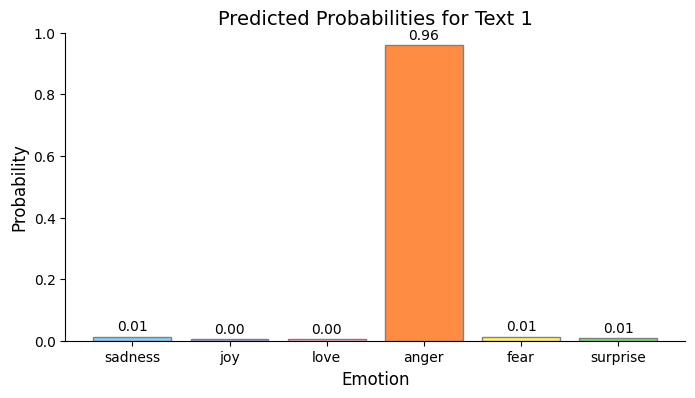

In [57]:
category_colors = {
    0: '#89CFF0',   # sadness
    1: '#B19CD9',   # joy
    2: '#FFB6C1',   # love
    3: '#FF8C42',   # anger
    4: '#FFF176',   # fear
    5: '#77DD77'    # surprise
}

for i, text in enumerate(new_texts[:5]):  # first 5 texts
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_title(f"Predicted Probabilities for Text {i+1}", fontsize=14)

    prob_values = probs[i]
    category_labels = [categories[j] for j in range(len(prob_values))]
    colors = [category_colors[j] for j in range(len(prob_values))]

    ax.bar(category_labels, prob_values, color=colors, edgecolor='gray')
    ax.set_ylim(0, 1)
    ax.set_ylabel("Probability", fontsize=12)
    ax.set_xlabel("Emotion", fontsize=12)

    # Show values on top of bars
    for idx, val in enumerate(prob_values):
        ax.text(idx, val + 0.02, f"{val:.2f}", ha='center', fontsize=10)

    # Remove top & right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()


# LSTM Neural Network

* A Neural Network is a computational model inspired by the human brain. It is made of layers of interconnected nodes (neurons) that process data.
* LSTM is a special type of Recurrent Neural Network (RNN) designed to handle sequential data (like text, time series).

In [53]:
df = pd.read_csv(r"C:\Users\dell\Downloads\datasets\data.csv")

In [54]:
def clean_text(text):
    text = text.lower()                          # lowercase
    text = contractions.fix(text)                # expand contractions
    text = re.sub(r"<.*?>", " ", text)           # remove HTML
    text = re.sub(r"http\S+|www\S+", " ", text)  # remove URLs
    text = re.sub(r"\S+@\S+\.\S+", " ", text)    # remove emails
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")  
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text


In [55]:
df['text'] = df['text'].apply(clean_text)

In [8]:
# Text length in characters
df["char_count"] = df["text"].apply(len)

# Word count
df["word_count"] = df["text"].apply(lambda x: len(x.split()))


In [23]:
df[["char_count","word_count"]].describe()

,char_count,word_count
count,416809.000000,416809.000000
mean,97.759449,19.519439
std,56.496030,11.177186
min,2.000000,1.000000
25%,54.000000,11.000000
50%,86.000000,17.000000
75%,129.000000,26.000000
max,832.000000,179.000000


In [58]:
texts = df["text"]
labels = df["label"]

In [17]:
texts

0         i feel awful about it too because it s my job ...
1                                   i am alone i feel awful
2         i have probably mentioned this before but i re...
3                  i was feeling a little low few days back
4         i beleive that i am much more sensitive to oth...
                                ...                        
416804    that was what i felt when i was finally accept...
416805    i take every day as it comes i m just focussin...
416806        i just suddenly feel that everything was fake
416807    i am feeling more eager than ever to claw back...
416808    i give you plenty of attention even when i fee...
Name: text, Length: 416809, dtype: object

In [19]:
labels

0         0
1         0
2         1
3         0
4         2
         ..
416804    1
416805    4
416806    0
416807    1
416808    0
Name: label, Length: 416809, dtype: int64

In [27]:
# Combine all texts into one big string
all_words = " ".join(df["text"]).split()
# Convert to a set to keep only unique words
vocab_size = len(set(all_words))
print("Vocabulary size:", vocab_size)

Vocabulary size: 75158


In [59]:
word_freq = Counter(" ".join(df["text"]).split())
most_common_words = sum([freq for _, freq in word_freq.most_common(30000)])
coverage = most_common_words / sum(word_freq.values())
print(f"Coverage with 30k words: {coverage:.2%}")


Coverage with 30k words: 99.31%


<Axes: >

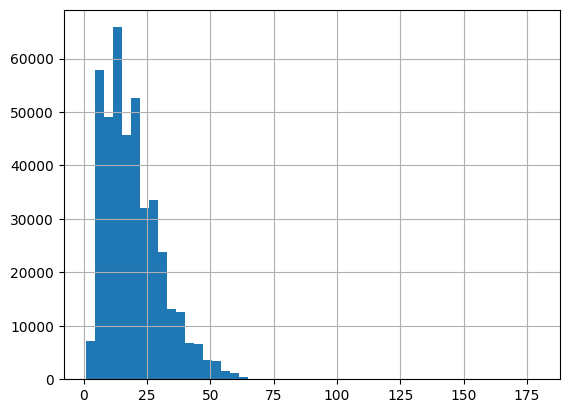

In [45]:
df["word_count"].hist(bins=50)

In [60]:
MAX_VOCAB = 30000   # keep the 30k most frequent words
MAX_LEN = 70       # each input will be exactly 70 tokens long

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<UNK>")
tokenizer.fit_on_texts(texts)                 # build the word→index dictionary
sequences = tokenizer.texts_to_sequences(texts)  # convert each text -> list of ints
X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post")
X.shape

(416809, 70)

* num_words=MAX_VOCAB --> only the top MAX_VOCAB words are kept; the rest (rare words) with an "UNK" (unknown) token.
* fit_on_texts: learns the vocabulary and frequency order from corpus.
* texts_to_sequences: replaces each token with its integer id.
* pad_sequences: every sequence becomes length MAX_LEN.
* padding="post" pads at the end with zeros if it’s shorter. If longer, it truncates to the first MAX_LEN tokens.
* Shapes:
  * Before padding: a Python list of variable-length lists.
  * After padding: X.shape == (num_samples, MAX_LEN) → a 2D int array.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42
)

In [64]:
first_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(128),
    Dense(64, activation="relu"),
    Dense(len(np.unique(labels)), activation="softmax")
])

E:\ANACONDA\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


---------------------------------------------
* Sequential:
  * A Sequential model is a linear stack of layers (you add layers one after another).
* Embedding:
  * The Embedding layer converts integer-encoded words into dense vectors.
  * input_dim=MAX_VOCAB: size of your word index space (indices go from 1..MAX_VOCAB-1; 0 is pad).
  * output_dim=128: each word id becomes a 128-dimensional vector. Tuneable (e.g., 100–300).
  * input_length=MAX_LEN: ensures sequences = same size (padded/truncated)

* LSTM(128):
  *  Adds an LSTM layer (Long Short-Term Memory).
  *  128 → number of LSTM units (memory cells). Each unit learns long-term dependencies in the sequence.
  *   The LSTM processes the embeddings sequence and outputs a fixed-size vector (summary of the sentence).
* Dense(64, relu):
  * A fully connected (dense) layer with 64 neurons.
  * a small feed-forward layer to mix the representation from LSTM.
  * Uses the ReLU (Rectified Linear Unit) activation function:
    * Outputs max(0, x), introducing non-linearity.
    * Helps the network learn complex patterns.

* Dense(num_classes, softmax):
  * output probabilities over your classes.
  * len(np.unique(labels)) = number of classes. case (0..5), this is 6.
  * softmax → activation function that turns raw scores into probabilities, Ensures all outputs sum to 1.

* Summary of flow:
  * Text → Tokenized & padded → Embedding → LSTM (sequence understanding) → Dense (feature learning) → Dense (classification with softmax).

----------------------------------------------------------------
My model has 4 layers:
* Embedding Layer
  * First layer.
  * Converts each word index into a 128-dimensional vector.
  * Helps the model learn semantic meaning of words.

* LSTM Layer
  * Second layer.
  * A recurrent layer with 128 memory units (neurons).
  * Processes the sequence and captures context & order of words.

* Dense Layer (Hidden Layer)
  * Third layer.
  * A fully connected layer with 64 neurons.
  * Learns complex patterns from the LSTM output.
  * Uses ReLU activation for non-linearity.
 
* Dense Layer (Output Layer)
  * Fourth layer (final).
  * Fully connected output layer.
  * Number of neurons = number of classes in your dataset.
  * Softmax activation gives probability distribution over classes.

-----------------------------------------------------------

In [65]:
first_model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

* loss:
  * Use "sparse_categorical_crossentropy" when labels are integer-encoded (0..K-1).
* optimizer: "adam" is a good default.
* metrics: track accuracy during training and validation.

In [66]:
history = first_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
4169/4169 ━━━━━━━━━━━━━━━━━━━━ 639s 150ms/step - accuracy: 0.3363 - loss: 1.5766 - val_accuracy: 0.3393 - val_loss: 1.5738
Epoch 2/5
4169/4169 ━━━━━━━━━━━━━━━━━━━━ 612s 147ms/step - accuracy: 0.3378 - loss: 1.5745 - val_accuracy: 0.3393 - val_loss: 1.5743
Epoch 3/5
4169/4169 ━━━━━━━━━━━━━━━━━━━━ 621s 146ms/step - accuracy: 0.4532 - loss: 1.2695 - val_accuracy: 0.8642 - val_loss: 0.3888
Epoch 4/5
4169/4169 ━━━━━━━━━━━━━━━━━━━━ 610s 146ms/step - accuracy: 0.9266 - loss: 0.1585 - val_accuracy: 0.9363 - val_loss: 0.1119
Epoch 5/5
4169/4169 ━━━━━━━━━━━━━━━━━━━━ 641s 151ms/step - accuracy: 0.9359 - loss: 0.1115 - val_accuracy: 0.9377 - val_loss: 0.1030


* validation_split=0.2: the model uses 20% of the training data to monitor validation metrics (not the test set).
* epochs=5: number of passes over the training set. Increase until val metrics stop improving.
* batch_size=64: how many samples per gradient update. Memory/speed trade-off.
* history: holds losses and accuracies per epoch (history.history dictionary).

In [21]:
loss, acc = first_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {acc:.4f}")

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step - accuracy: 0.9387 - loss: 0.0936
Test Accuracy: 0.9387


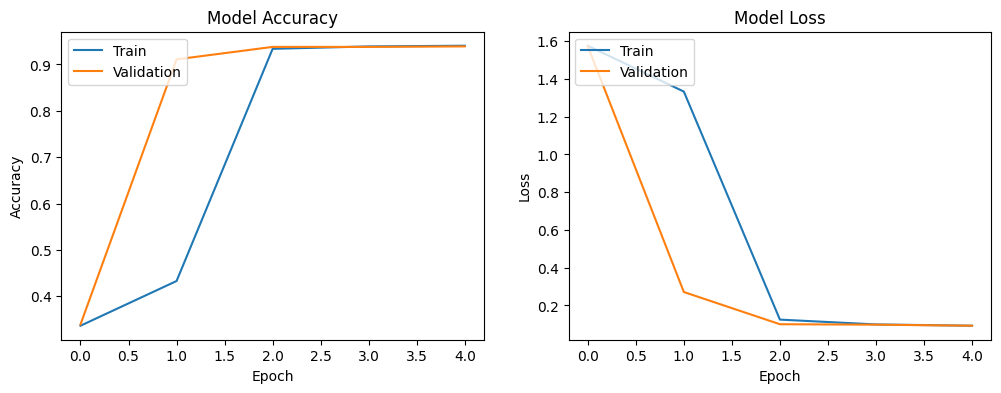

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [23]:
first_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 70, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,940,692 (45.55 MB)

 Trainable params: 3,980,230 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,960,462 (30.37 MB)

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step


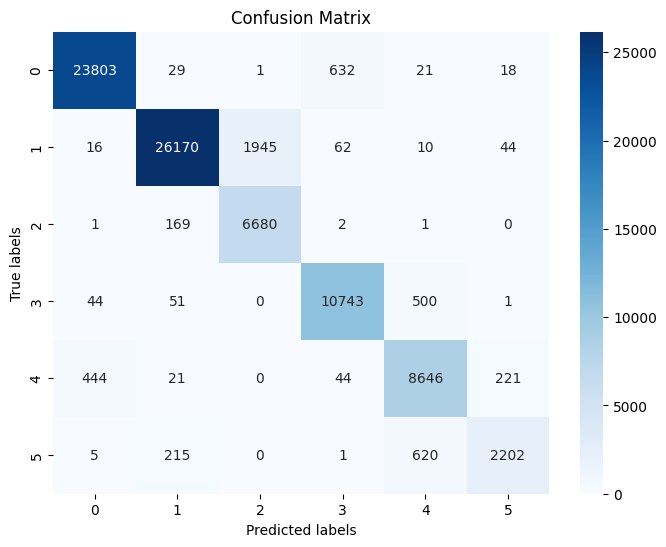

In [115]:
y_pred = first_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with blue color
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Change 'Reds' to 'Blues' for blue color
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Texts to predict
new_texts  = [
    # Sadness
    "I feel heartbroken after hearing the news.",
    "It’s so lonely when no one calls me back.",
    "I miss my childhood days and friends.",
    "The rainy weather makes me feel so gloomy.",
    "I can’t stop crying after that movie ended.",
    
    # Joy
    "I’m over the moon about my exam results!",
    "Nothing beats the feeling of winning a game.",
    "I’m so happy to finally meet my favorite author.",
    "Celebrating my birthday with friends is amazing.",
    "I just got a puppy, I’m thrilled!",

    # Love
    "I love spending weekends with my partner.",
    "My family means the world to me.",
    "I feel so affectionate towards my little niece.",
    "Holding hands with my soulmate makes me feel warm.",
    "Sending love and hugs to all my friends.",

    # Anger
    "I am furious about the unfair treatment.",
    "This traffic jam is making me so angry!",
    "I can’t stand people lying to me.",
    "Someone stole my wallet, I’m enraged!",
    "I feel frustrated that nothing is going right.",

    # Fear
    "Walking alone at night scares me.",
    "I’m terrified of failing my finals.",
    "The thought of losing my job frightens me.",
    "That horror movie made me panic!",
    "I’m anxious about the storm coming tonight.",

    # Surprise
    "Wow! I didn’t expect this gift at all!",
    "I’m shocked by the sudden announcement.",
    "What a surprise party, I can’t believe it!",
    "I’m amazed at how quickly they solved the problem.",
    "I never thought I’d see her here, what a surprise!"
]

# Preprocess texts
new_texts = [clean_text(text) for text in new_texts]
seqs = tokenizer.texts_to_sequences(new_texts)
X_new = pad_sequences(seqs, maxlen=MAX_LEN, padding="post")

# Get probabilities and predictions
probs = first_model.predict(X_new)
pred_classes = probs.argmax(axis=1)

# Map numbers to categories
label_map = {0:"sadness", 1:"joy", 2:"love", 3:"anger", 4:"fear", 5:"surprise"}

# Display results
for i, text in enumerate(new_texts):
    print("Original:", text)
    print("Predicted:", label_map[pred_classes[i]])
    
    # Format probabilities
    prob_text = ", ".join([f"{label_map[j]}:{probs[i][j]:.2f}" for j in range(len(probs[i]))])
    print("Probabilities:", prob_text)
    print("---------------------")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
Original: i feel heartbroken after hearing the news.
Predicted: sadness
Probabilities: sadness:1.00, joy:0.00, love:0.00, anger:0.00, fear:0.00, surprise:0.00
---------------------
Original: it is so lonely when no one calls me back.
Predicted: sadness
Probabilities: sadness:0.80, joy:0.01, love:0.00, anger:0.11, fear:0.08, surprise:0.00
---------------------
Original: i miss my childhood days and friends.
Predicted: anger
Probabilities: sadness:0.36, joy:0.14, love:0.00, anger:0.40, fear:0.10, surprise:0.00
---------------------
Original: the rainy weather makes me feel so gloomy.
Predicted: sadness
Probabilities: sadness:1.00, joy:0.00, love:0.00, anger:0.00, fear:0.00, surprise:0.00
---------------------
Original: i cannot stop crying after that movie ended.
Predicted: sadness
Probabilities: sadness:0.46, joy:0.08, love:0.00, anger:0.38, fear:0.09, surprise:0.00
---------------------
Original: i am over the moon about my exam results!
Predicted

Original: I feel heartbroken after hearing the news.
Predicted: sadness
Probabilities: sadness:1.00, joy:0.00, love:0.00, anger:0.00, fear:0.00, surprise:0.00
---------------------


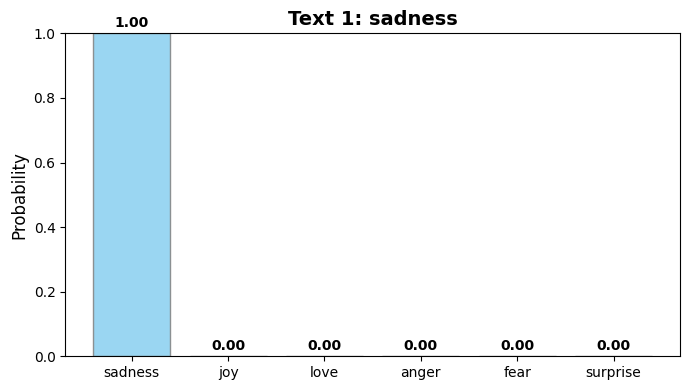

Original: It’s so lonely when no one calls me back.
Predicted: anger
Probabilities: sadness:0.29, joy:0.01, love:0.00, anger:0.45, fear:0.26, surprise:0.00
---------------------


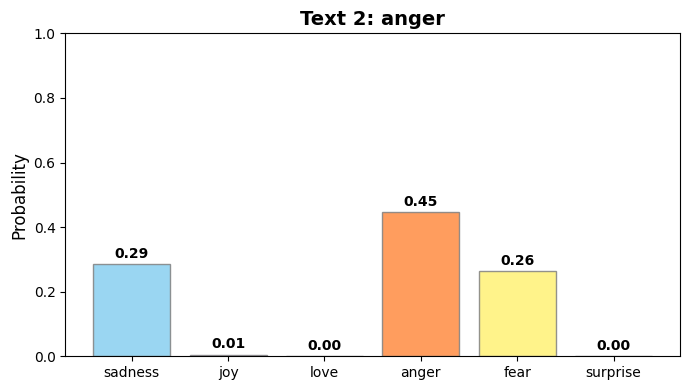

Original: I miss my childhood days and friends.
Predicted: joy
Probabilities: sadness:0.17, joy:0.63, love:0.00, anger:0.15, fear:0.05, surprise:0.00
---------------------


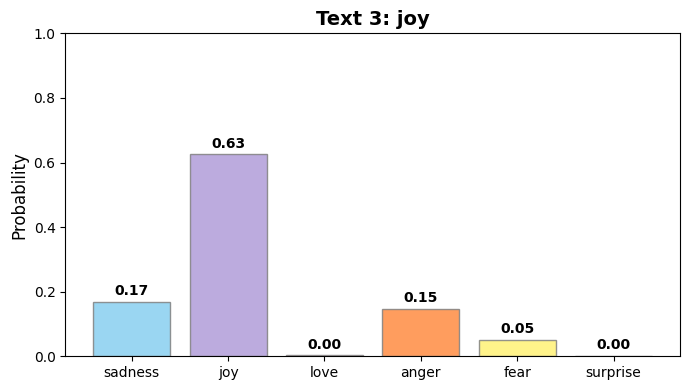

Original: The rainy weather makes me feel so gloomy.
Predicted: sadness
Probabilities: sadness:1.00, joy:0.00, love:0.00, anger:0.00, fear:0.00, surprise:0.00
---------------------


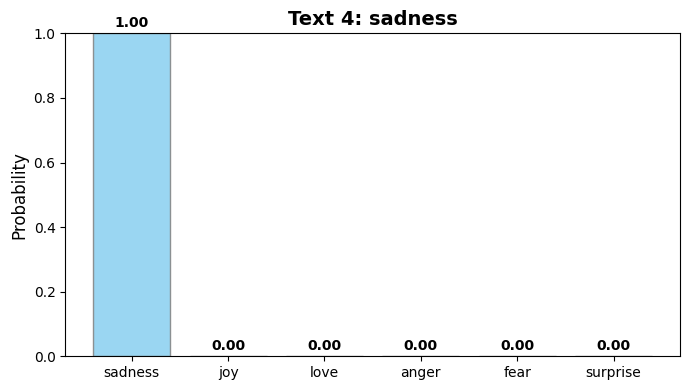

Original: I can’t stop crying after that movie ended.
Predicted: fear
Probabilities: sadness:0.05, joy:0.29, love:0.00, anger:0.07, fear:0.58, surprise:0.01
---------------------


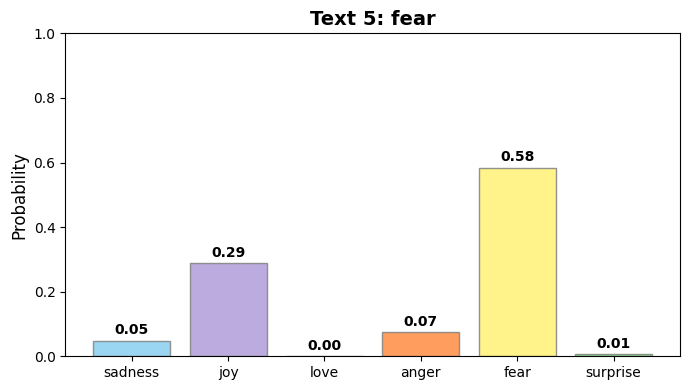

Original: I’m over the moon about my exam results!
Predicted: fear
Probabilities: sadness:0.11, joy:0.16, love:0.00, anger:0.15, fear:0.57, surprise:0.00
---------------------


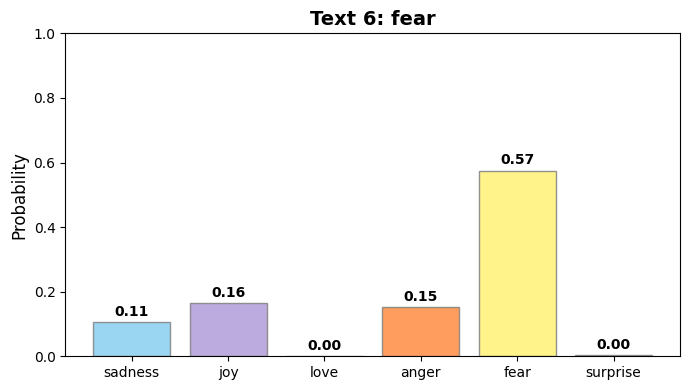

Original: Nothing beats the feeling of winning a game.
Predicted: joy
Probabilities: sadness:0.00, joy:0.97, love:0.03, anger:0.00, fear:0.00, surprise:0.00
---------------------


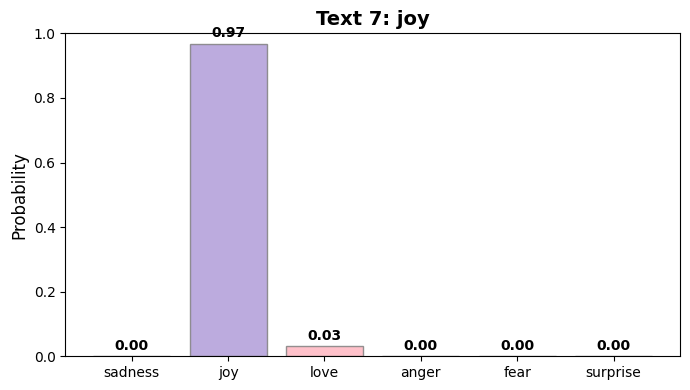

Original: I’m so happy to finally meet my favorite author.
Predicted: joy
Probabilities: sadness:0.08, joy:0.86, love:0.00, anger:0.04, fear:0.01, surprise:0.00
---------------------


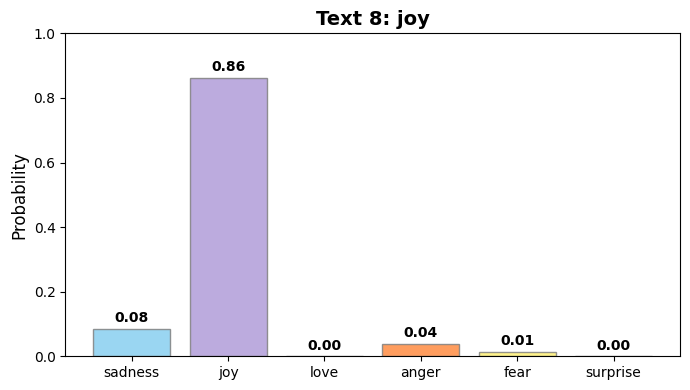

Original: Celebrating my birthday with friends is amazing.
Predicted: joy
Probabilities: sadness:0.00, joy:0.52, love:0.00, anger:0.00, fear:0.04, surprise:0.44
---------------------


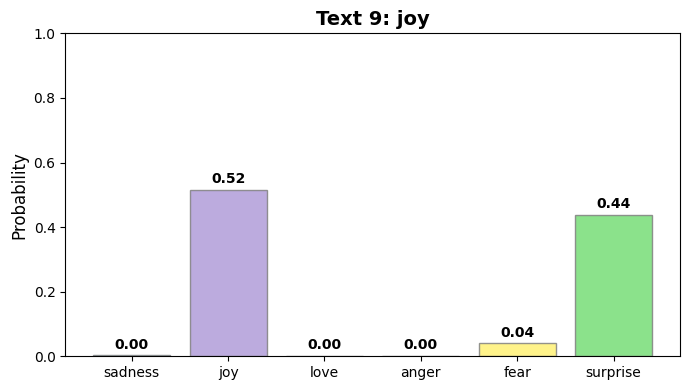

Original: I just got a puppy, I’m thrilled!
Predicted: joy
Probabilities: sadness:0.03, joy:0.91, love:0.00, anger:0.04, fear:0.02, surprise:0.00
---------------------


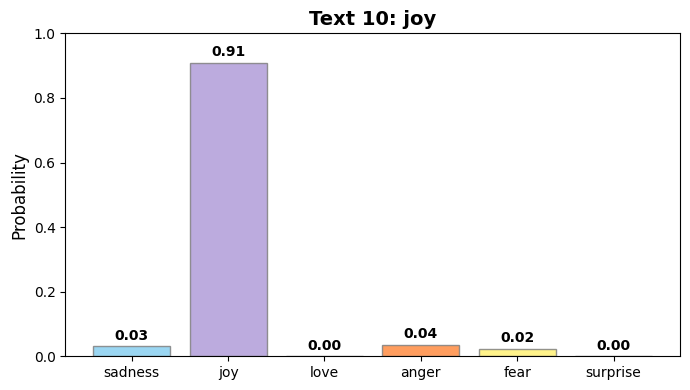

Original: I love spending weekends with my partner.
Predicted: joy
Probabilities: sadness:0.08, joy:0.85, love:0.00, anger:0.04, fear:0.03, surprise:0.00
---------------------


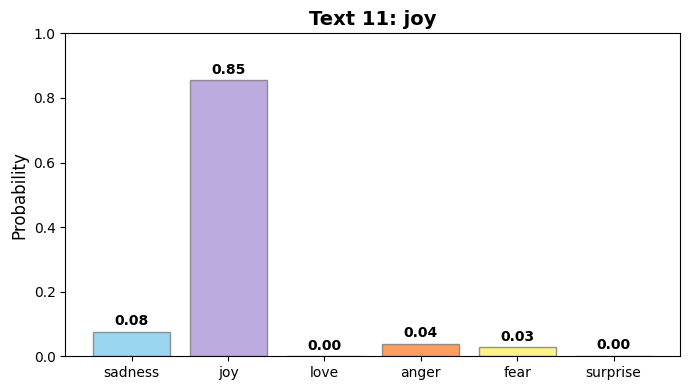

Original: My family means the world to me.
Predicted: anger
Probabilities: sadness:0.33, joy:0.10, love:0.00, anger:0.48, fear:0.09, surprise:0.00
---------------------


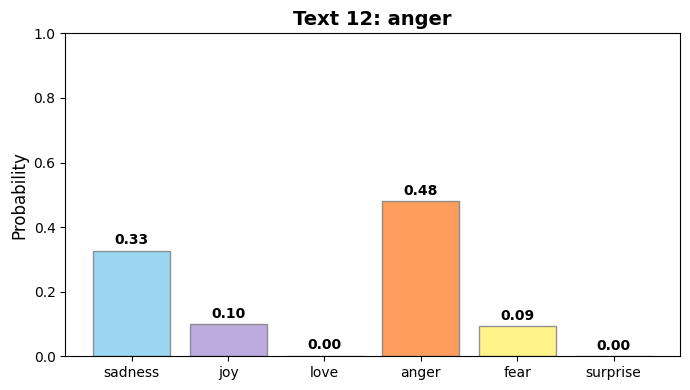

Original: I feel so affectionate towards my little niece.
Predicted: love
Probabilities: sadness:0.00, joy:0.00, love:1.00, anger:0.00, fear:0.00, surprise:0.00
---------------------


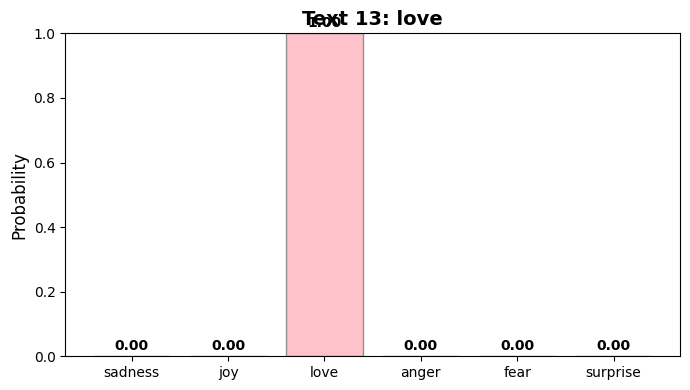

Original: Holding hands with my soulmate makes me feel warm.
Predicted: joy
Probabilities: sadness:0.06, joy:0.84, love:0.06, anger:0.03, fear:0.00, surprise:0.00
---------------------


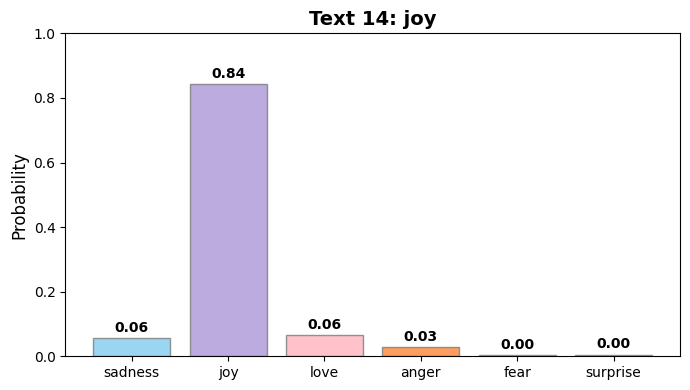

Original: Sending love and hugs to all my friends.
Predicted: fear
Probabilities: sadness:0.07, joy:0.21, love:0.00, anger:0.16, fear:0.55, surprise:0.01
---------------------


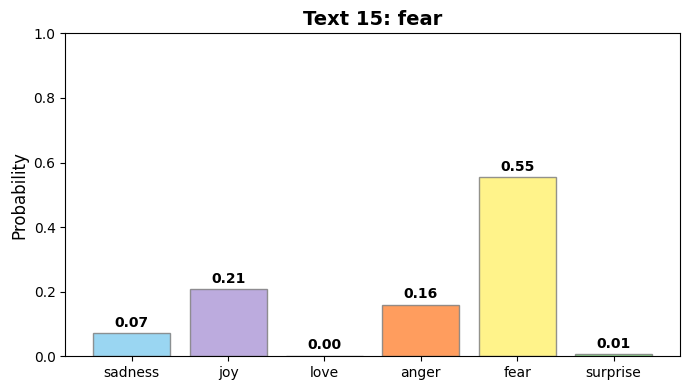

Original: I am furious about the unfair treatment.
Predicted: anger
Probabilities: sadness:0.00, joy:0.00, love:0.00, anger:0.99, fear:0.00, surprise:0.00
---------------------


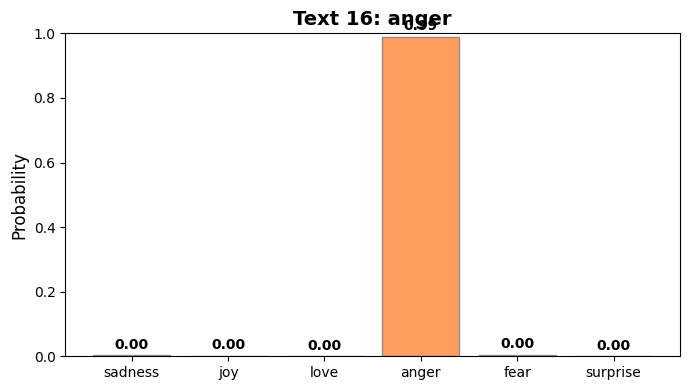

Original: This traffic jam is making me so angry!
Predicted: anger
Probabilities: sadness:0.01, joy:0.00, love:0.00, anger:0.98, fear:0.01, surprise:0.00
---------------------


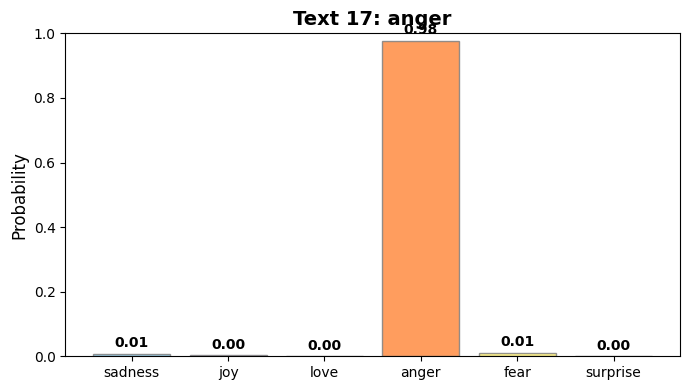

Original: I can’t stand people lying to me.
Predicted: anger
Probabilities: sadness:0.11, joy:0.28, love:0.01, anger:0.50, fear:0.10, surprise:0.00
---------------------


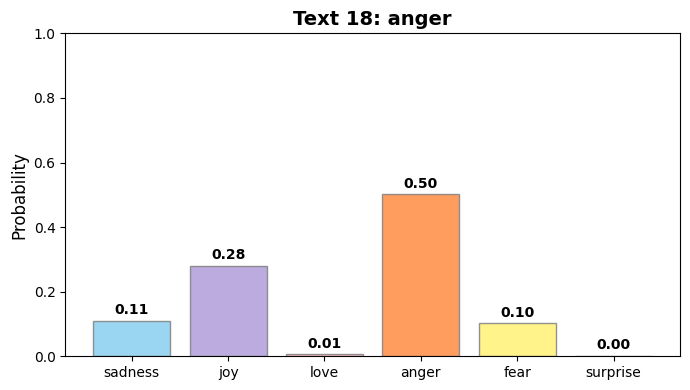

Original: Someone stole my wallet, I’m enraged!
Predicted: anger
Probabilities: sadness:0.00, joy:0.00, love:0.00, anger:0.99, fear:0.01, surprise:0.00
---------------------


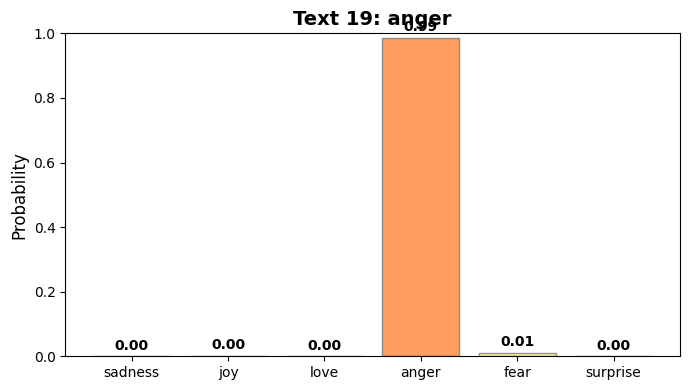

Original: I feel frustrated that nothing is going right.
Predicted: anger
Probabilities: sadness:0.00, joy:0.00, love:0.00, anger:1.00, fear:0.00, surprise:0.00
---------------------


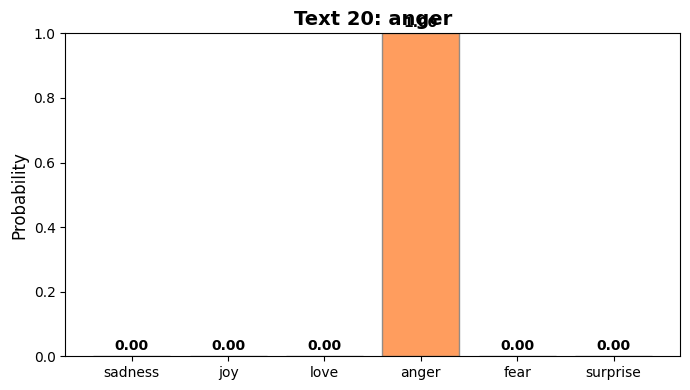

Original: Walking alone at night scares me.
Predicted: fear
Probabilities: sadness:0.03, joy:0.00, love:0.00, anger:0.03, fear:0.94, surprise:0.00
---------------------


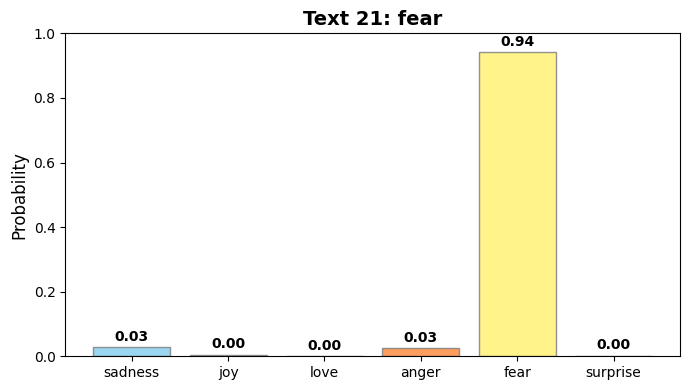

Original: I’m terrified of failing my finals.
Predicted: fear
Probabilities: sadness:0.00, joy:0.00, love:0.00, anger:0.01, fear:0.99, surprise:0.00
---------------------


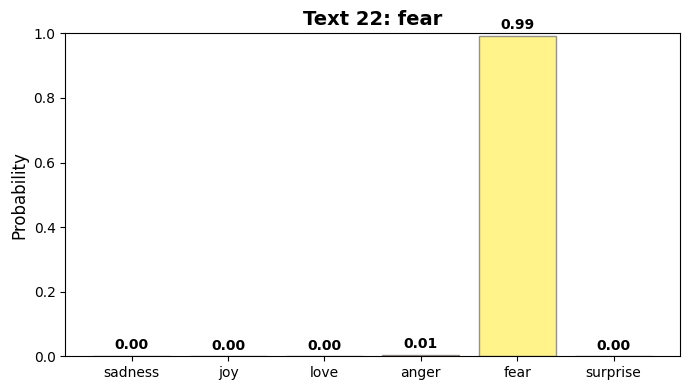

Original: The thought of losing my job frightens me.
Predicted: sadness
Probabilities: sadness:0.74, joy:0.05, love:0.00, anger:0.15, fear:0.06, surprise:0.00
---------------------


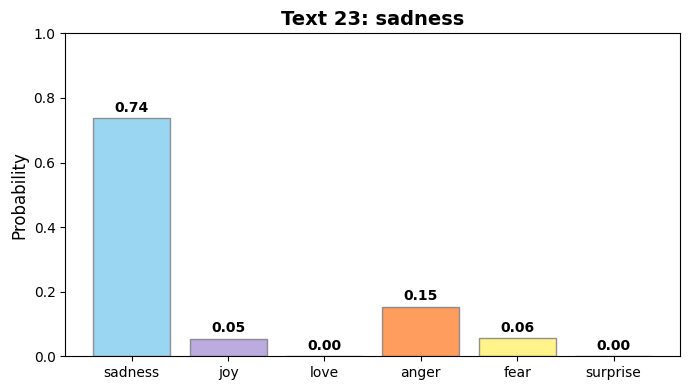

Original: That horror movie made me panic!
Predicted: fear
Probabilities: sadness:0.00, joy:0.02, love:0.00, anger:0.01, fear:0.96, surprise:0.00
---------------------


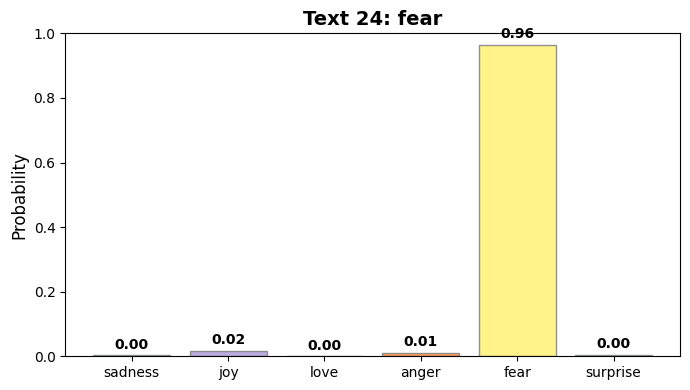

Original: I’m anxious about the storm coming tonight.
Predicted: fear
Probabilities: sadness:0.00, joy:0.00, love:0.00, anger:0.01, fear:0.98, surprise:0.00
---------------------


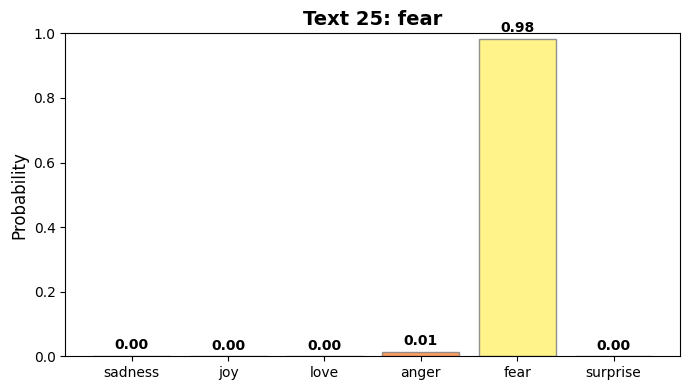

Original: Wow! I didn’t expect this gift at all!
Predicted: fear
Probabilities: sadness:0.12, joy:0.06, love:0.00, anger:0.24, fear:0.58, surprise:0.00
---------------------


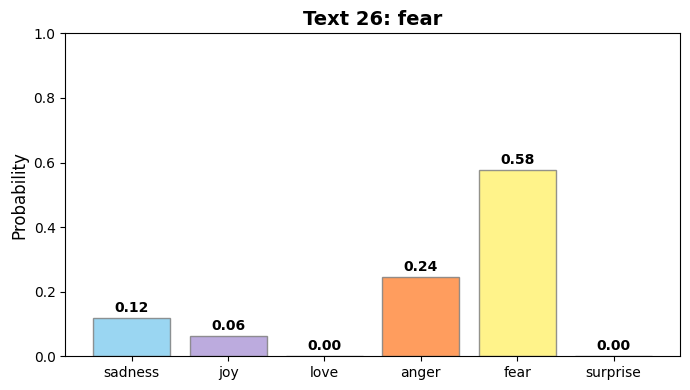

Original: I’m shocked by the sudden announcement.
Predicted: surprise
Probabilities: sadness:0.00, joy:0.01, love:0.00, anger:0.00, fear:0.06, surprise:0.93
---------------------


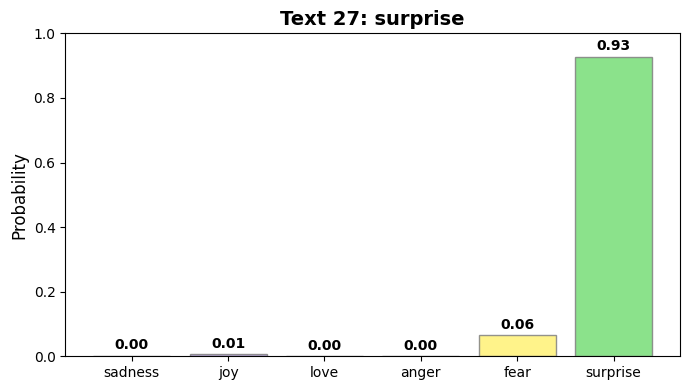

Original: What a surprise party, I can’t believe it!
Predicted: joy
Probabilities: sadness:0.19, joy:0.43, love:0.00, anger:0.25, fear:0.13, surprise:0.00
---------------------


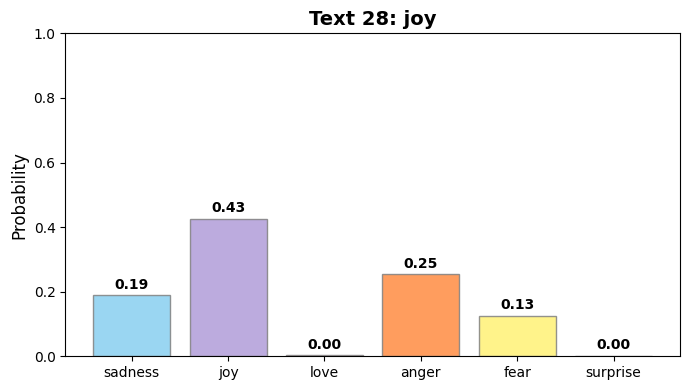

Original: I’m amazed at how quickly they solved the problem.
Predicted: surprise
Probabilities: sadness:0.00, joy:0.01, love:0.00, anger:0.00, fear:0.01, surprise:0.99
---------------------


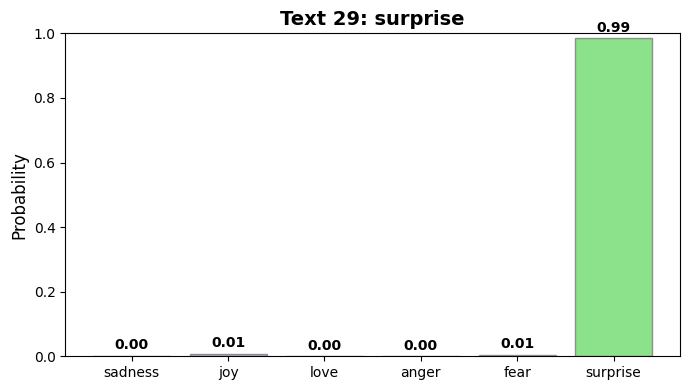

Original: I never thought I’d see her here, what a surprise!
Predicted: joy
Probabilities: sadness:0.21, joy:0.56, love:0.00, anger:0.12, fear:0.11, surprise:0.00
---------------------


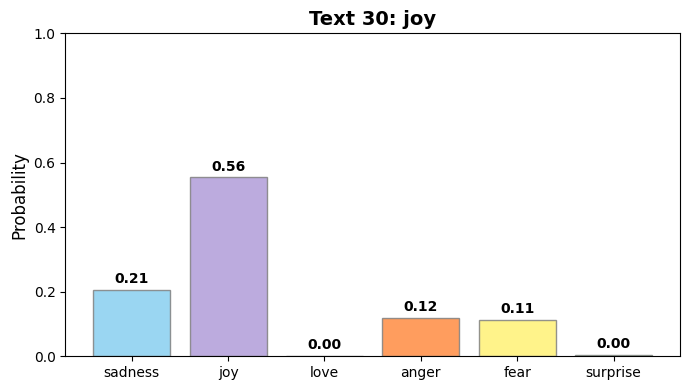

In [87]:
# Define colors for each category
category_colors = {
    0: '#89CFF0',   
    1: '#B19CD9',   
    2: '#FFB6C1',   
    3: '#FF8C42',   
    4: '#FFF176',   
    5: '#77DD77'   
}

# Display results + visualization
for i, text in enumerate(new_texts):
    print("Original:", text)
    print("Predicted:", label_map[pred_classes[i]])
    
    # Format probabilities for printing
    prob_text = ", ".join([f"{label_map[j]}:{probs[i][j]:.2f}" for j in range(len(probs[i]))])
    print("Probabilities:", prob_text)
    print("---------------------")

    # --- Visualization ---
    plt.figure(figsize=(7,4))
    plt.title(f"Text {i+1}: {label_map[pred_classes[i]]}", fontsize=14, weight="bold")
    
    prob_values = probs[i]
    categories = [label_map[j] for j in range(len(prob_values))]
    colors = [category_colors[j] for j in range(len(prob_values))]

    bars = plt.bar(categories, prob_values, color=colors, edgecolor="gray", alpha=0.85)
    plt.ylim(0, 1)
    plt.ylabel("Probability", fontsize=12)
    
    # Annotate probabilities above bars
    for bar, val in zip(bars, prob_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f"{val:.2f}", ha='center', fontsize=10, weight="bold")

    plt.tight_layout()
    plt.show()


In [77]:
first_model.save("model.keras")

In [170]:
model.save("model.keras")
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [79]:
with open("tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)


In [81]:
loaded_model = load_model("model.keras")